# Integrated Monthly Base EDA

Exploratory analysis for the integrated monthly base table, before `create_feature_table.py` adds lagged, rolling, target, seasonal, and regime features.

Goals:

- Inspect coverage, gaps, and source availability across the joined monthly data.
- Study spread and distributions for each raw numeric datapoint.
- Look at pairwise relationships and correlations before feature engineering.
- Keep this notebook focused on source data behavior rather than model-ready feature behavior.


## Navigation Notes

Key MoM comparison sections:

- `Pre-2020 Month-Over-Month Change By Calendar Month`: baseline monthly movement through December 2019.
- `Full-Series Month-Over-Month Change By Calendar Month`: same raw MoM method across the entire series, including COVID and recovery.
- `Full-Series Average MoM Minus Pre-2020 Average MoM`: percentage-point difference between those two views.


In [1]:
from __future__ import annotations

from pathlib import Path
from pandas.plotting import scatter_matrix

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.3f}".format)
plt.style.use("seaborn-v0_8-whitegrid")


## Load Integrated Data

This uses the local integrated artifact produced before feature-table creation. If you want to point at a different run, update `INTEGRATED_PARQUET` to another local `integrated_monthly_base.parquet` file.


In [2]:
PROJECT_ROOT = Path.cwd()
INTEGRATED_PARQUET = PROJECT_ROOT / "raw_files" / "integrated_monthly_base.parquet"

if not INTEGRATED_PARQUET.exists():
    raise FileNotFoundError(f"Missing integrated parquet: {INTEGRATED_PARQUET}")

df = pd.read_parquet(INTEGRATED_PARQUET)
df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
df = df.sort_values("date").reset_index(drop=True)

print(f"Loaded: {INTEGRATED_PARQUET}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()


Loaded: /Users/jonsellers/Documents/transit_project_2026/raw_files/integrated_monthly_base.parquet
Shape: 291 rows x 21 columns
Date range: 2002-01-01 to 2026-03-01


,date,period_end,transit_available_at,transit_series_id,transit_source_name,upt,vrm,vrh,voms,gas_available_at,gas_series_id,gas_source_name,seattle_gas_price_avg,seattle_gas_price_std,weekly_obs_count,inflation_available_at,inflation_series_id,inflation_source_name,cpi_all_items_sa,cpi_core_sa,data_available_at
0,2002-01-01,2002-01-31,2002-02-07,king_county_mb_do_bus,ntd_complete_monthly_ridership_workbook,6045861.000,2878549.000,216788.000,931.000,NaT,None,None,NaN,NaN,NaN,2002-02-07,fred_monthly_inflation,fred_inflation,177.700,188.700,2002-02-07
1,2002-02-01,2002-02-28,2002-03-07,king_county_mb_do_bus,ntd_complete_monthly_ridership_workbook,5406135.000,2558164.000,192360.000,931.000,NaT,None,None,NaN,NaN,NaN,2002-03-07,fred_monthly_inflation,fred_inflation,178.000,189.100,2002-03-07
2,2002-03-01,2002-03-31,2002-04-07,king_county_mb_do_bus,ntd_complete_monthly_ridership_workbook,5999230.000,2840121.000,213519.000,931.000,NaT,None,None,NaN,NaN,NaN,2002-04-07,fred_monthly_inflation,fred_inflation,178.500,189.200,2002-04-07
3,2002-04-01,2002-04-30,2002-05-07,king_county_mb_do_bus,ntd_complete_monthly_ridership_workbook,6058398.000,2855047.000,213860.000,931.000,NaT,None,None,NaN,NaN,NaN,2002-05-07,fred_monthly_inflation,fred_inflation,179.300,189.700,2002-05-07
4,2002-05-01,2002-05-31,2002-06-07,king_county_mb_do_bus,ntd_complete_monthly_ridership_workbook,6134503.000,2899399.000,217418.000,931.000,NaT,None,None,NaN,NaN,NaN,2002-06-07,fred_monthly_inflation,fred_inflation,179.500,190.000,2002-06-07


## Column Groups


In [3]:
date_cols = [c for c in df.columns if c == "date" or c.endswith("_at") or c == "period_end"]
id_cols = [c for c in df.columns if c.endswith("_series_id") or c.endswith("_source_name")]
numeric_cols = df.select_dtypes(include="number").columns.tolist()

transit_cols = [c for c in ["upt", "vrm", "vrh", "voms"] if c in df.columns]
gas_cols = [c for c in df.columns if c.startswith("seattle_gas_price") or c == "weekly_obs_count"]
inflation_cols = [c for c in df.columns if c.startswith("cpi_")]
income_cols = [c for c in df.columns if "income" in c.lower()]

source_groups = {
    "transit": transit_cols,
    "gas": gas_cols,
    "inflation": inflation_cols,
    "income": income_cols,
}

pd.DataFrame(
    {
        "group": list(source_groups),
        "columns": [", ".join(cols) if cols else "not present" for cols in source_groups.values()],
        "count": [len(cols) for cols in source_groups.values()],
    }
)


,group,columns,count
0,transit,"upt, vrm, vrh, voms",4
1,gas,"seattle_gas_price_avg, seattle_gas_price_std, ...",3
2,inflation,"cpi_all_items_sa, cpi_core_sa",2
3,income,not present,0


## Structure And Coverage


In [4]:
monthly_index = pd.date_range(df["date"].min(), df["date"].max(), freq="MS")
missing_months = monthly_index.difference(df["date"])

coverage = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": [str(df[c].dtype) for c in df.columns],
        "non_null": [int(df[c].notna().sum()) for c in df.columns],
        "null_count": [int(df[c].isna().sum()) for c in df.columns],
        "null_pct": [df[c].isna().mean() for c in df.columns],
        "unique_count": [int(df[c].nunique(dropna=True)) for c in df.columns],
    }
).sort_values(["null_pct", "column"], ascending=[False, True])

print(f"Duplicate monthly dates: {df['date'].duplicated().sum():,}")
print(f"Missing months in date spine: {len(missing_months):,}")
display(coverage)
if len(missing_months):
    display(pd.DataFrame({"missing_month": missing_months}))


Duplicate monthly dates: 0
Missing months in date spine: 0


,column,dtype,non_null,null_count,null_pct,unique_count
9,gas_available_at,datetime64[ns],275,16,0.055,275
10,gas_series_id,object,275,16,0.055,1
11,gas_source_name,object,275,16,0.055,1
12,seattle_gas_price_avg,float64,275,16,0.055,275
13,seattle_gas_price_std,float64,275,16,0.055,275
14,weekly_obs_count,float64,275,16,0.055,3
18,cpi_all_items_sa,float64,290,1,0.003,284
19,cpi_core_sa,float64,290,1,0.003,287
20,data_available_at,datetime64[ns],291,0,0.000,291
0,date,datetime64[ns],291,0,0.000,291


## Availability Lag


In [5]:
availability_cols = [c for c in date_cols if c.endswith("_available_at")]
availability_lags = df[["date", *availability_cols]].copy()

for col in availability_cols:
    availability_lags[f"{col}_lag_days"] = (availability_lags[col] - availability_lags["date"]).dt.days

lag_cols = [c for c in availability_lags.columns if c.endswith("_lag_days")]
availability_lags[lag_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
transit_available_at_lag_days,291.000,36.433,0.825,34.000,36.000,37.000,37.000,37.000
gas_available_at_lag_days,275.000,36.440,0.814,34.000,36.000,37.000,37.000,37.000
inflation_available_at_lag_days,291.000,36.433,0.825,34.000,36.000,37.000,37.000,37.000
data_available_at_lag_days,291.000,36.433,0.825,34.000,36.000,37.000,37.000,37.000


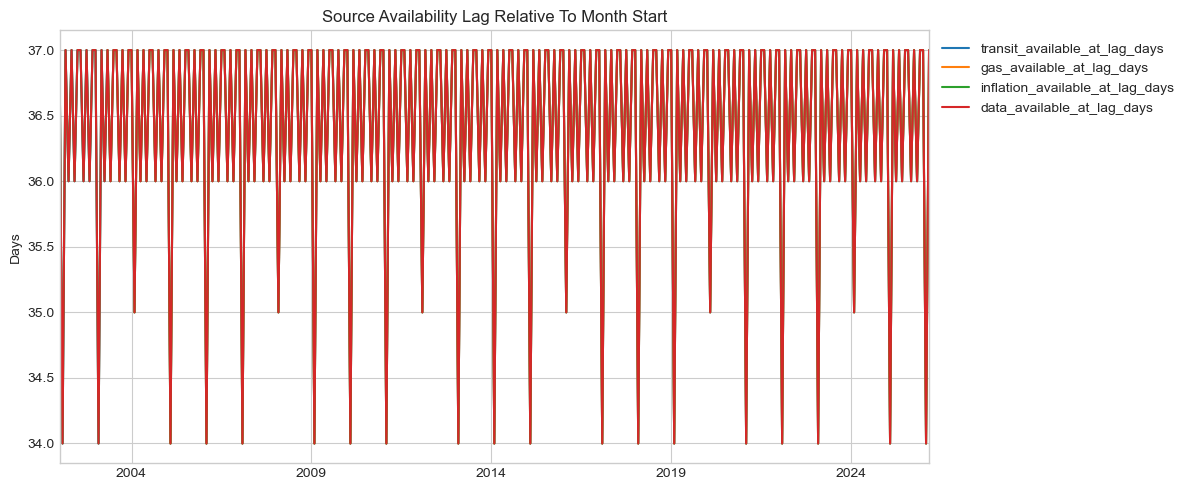

In [6]:
if lag_cols:
    fig, ax = plt.subplots(figsize=(12, 5))
    availability_lags.set_index("date")[lag_cols].plot(ax=ax)
    ax.set_title("Source Availability Lag Relative To Month Start")
    ax.set_ylabel("Days")
    ax.set_xlabel("")
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()


## Numeric Summary


In [7]:
numeric_summary = df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
numeric_summary["missing"] = df[numeric_cols].isna().sum()
numeric_summary["missing_pct"] = df[numeric_cols].isna().mean()
numeric_summary["skew"] = df[numeric_cols].skew(numeric_only=True)
numeric_summary.sort_index()


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing,missing_pct,skew
cpi_all_items_sa,290.000,239.003,39.908,177.700,179.212,183.145,211.567,235.018,257.698,317.120,326.092,330.293,1,0.003,0.594
cpi_core_sa,290.000,243.887,39.683,188.700,189.645,192.500,213.813,236.073,265.823,322.988,331.922,334.165,1,0.003,0.668
seattle_gas_price_avg,275.000,3.336,0.855,1.537,1.590,1.956,2.783,3.211,3.968,4.792,5.233,5.581,16,0.055,0.165
seattle_gas_price_std,275.000,0.059,0.052,0.000,0.003,0.009,0.022,0.044,0.074,0.152,0.232,0.411,16,0.055,2.475
upt,291.000,6852815.656,1571016.095,2532122.000,2731406.900,3462087.500,5958451.000,7098141.000,8120054.500,8816498.500,9227845.200,9619655.000,0,0.000,-0.747
voms,291.000,941.058,148.471,601.000,676.400,711.000,871.000,932.000,986.000,1185.000,1185.000,1185.000,0,0.000,0.208
vrh,291.000,228289.144,19931.002,160357.000,174360.000,196201.000,217231.500,226161.000,241298.000,259666.500,272692.800,283004.000,0,0.000,-0.254
vrm,291.000,2693207.770,218388.670,2282992.000,2341312.800,2457643.500,2570217.000,2666392.000,2763047.000,3046401.000,3197106.400,4885005.000,0,0.000,3.898
weekly_obs_count,275.000,4.338,0.518,1.000,4.000,4.000,4.000,4.000,5.000,5.000,5.000,5.000,16,0.055,-0.430


## Distributions


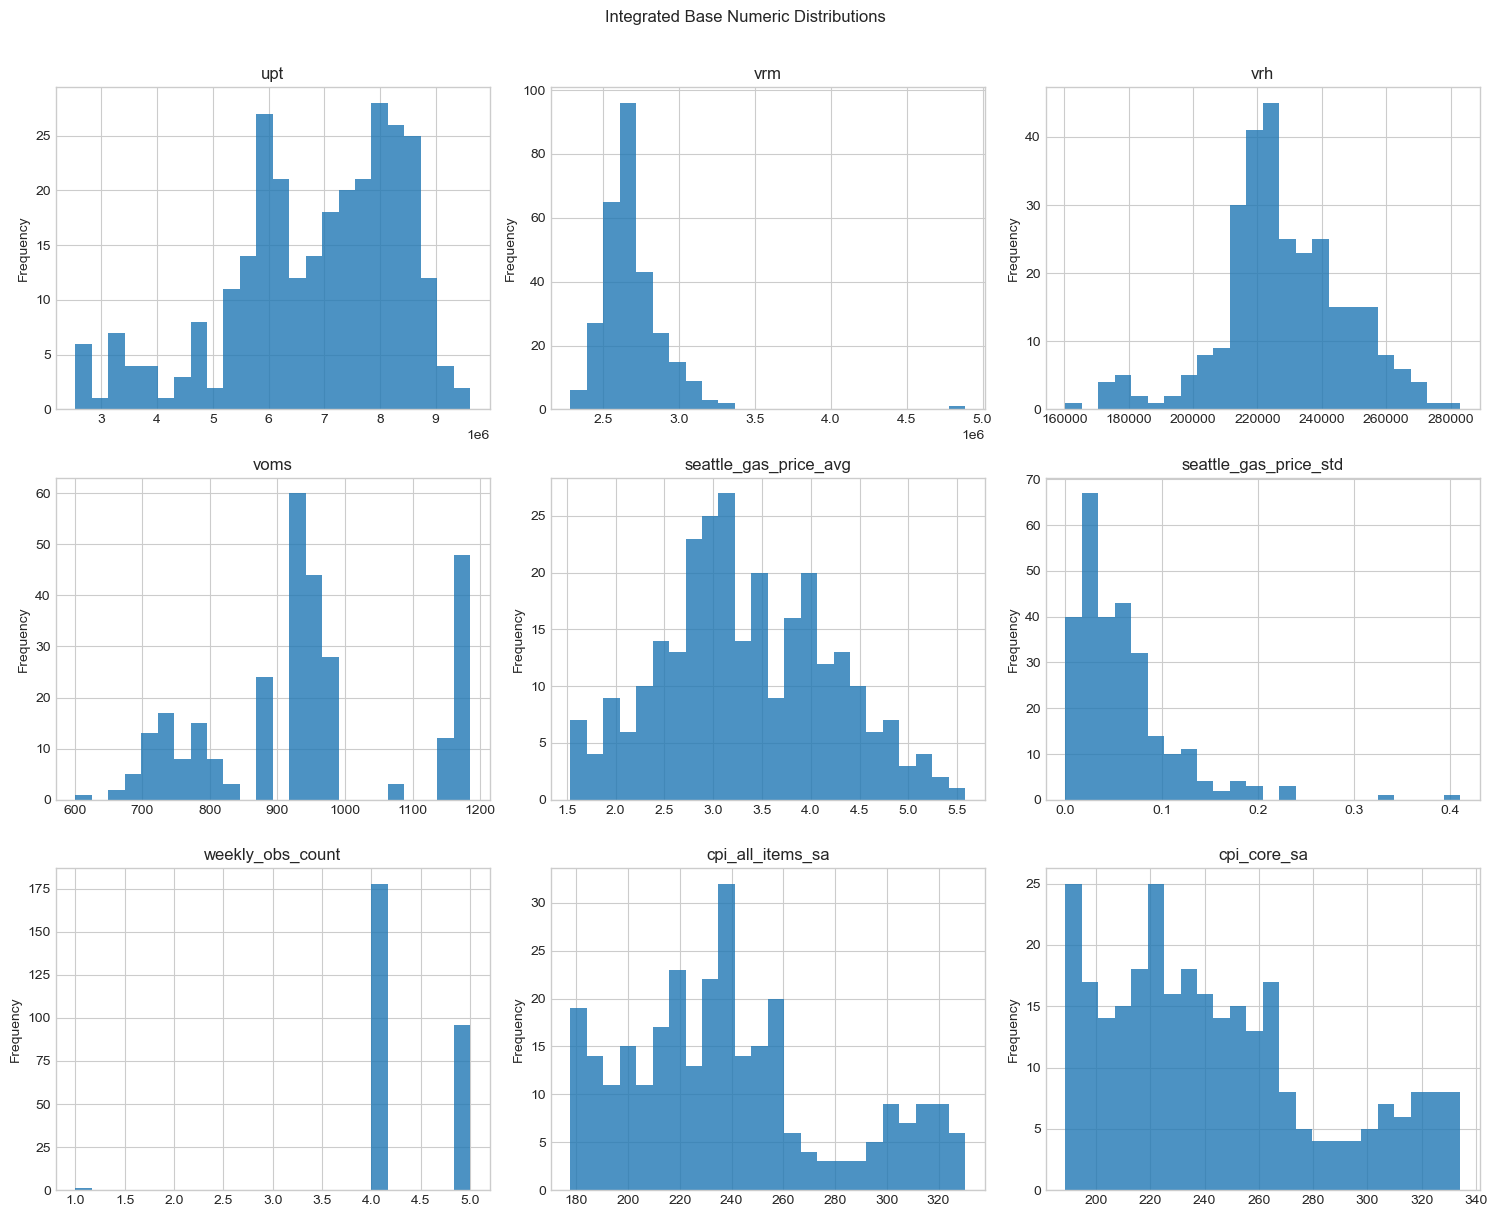

In [8]:
if numeric_cols:
    n_cols = 3
    n_rows = int(np.ceil(len(numeric_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, col in zip(axes, numeric_cols):
        df[col].dropna().plot(kind="hist", bins=24, ax=ax, alpha=0.8)
        ax.set_title(col)
        ax.set_xlabel("")

    for ax in axes[len(numeric_cols):]:
        ax.set_visible(False)

    fig.suptitle("Integrated Base Numeric Distributions", y=1.01)
    plt.tight_layout()


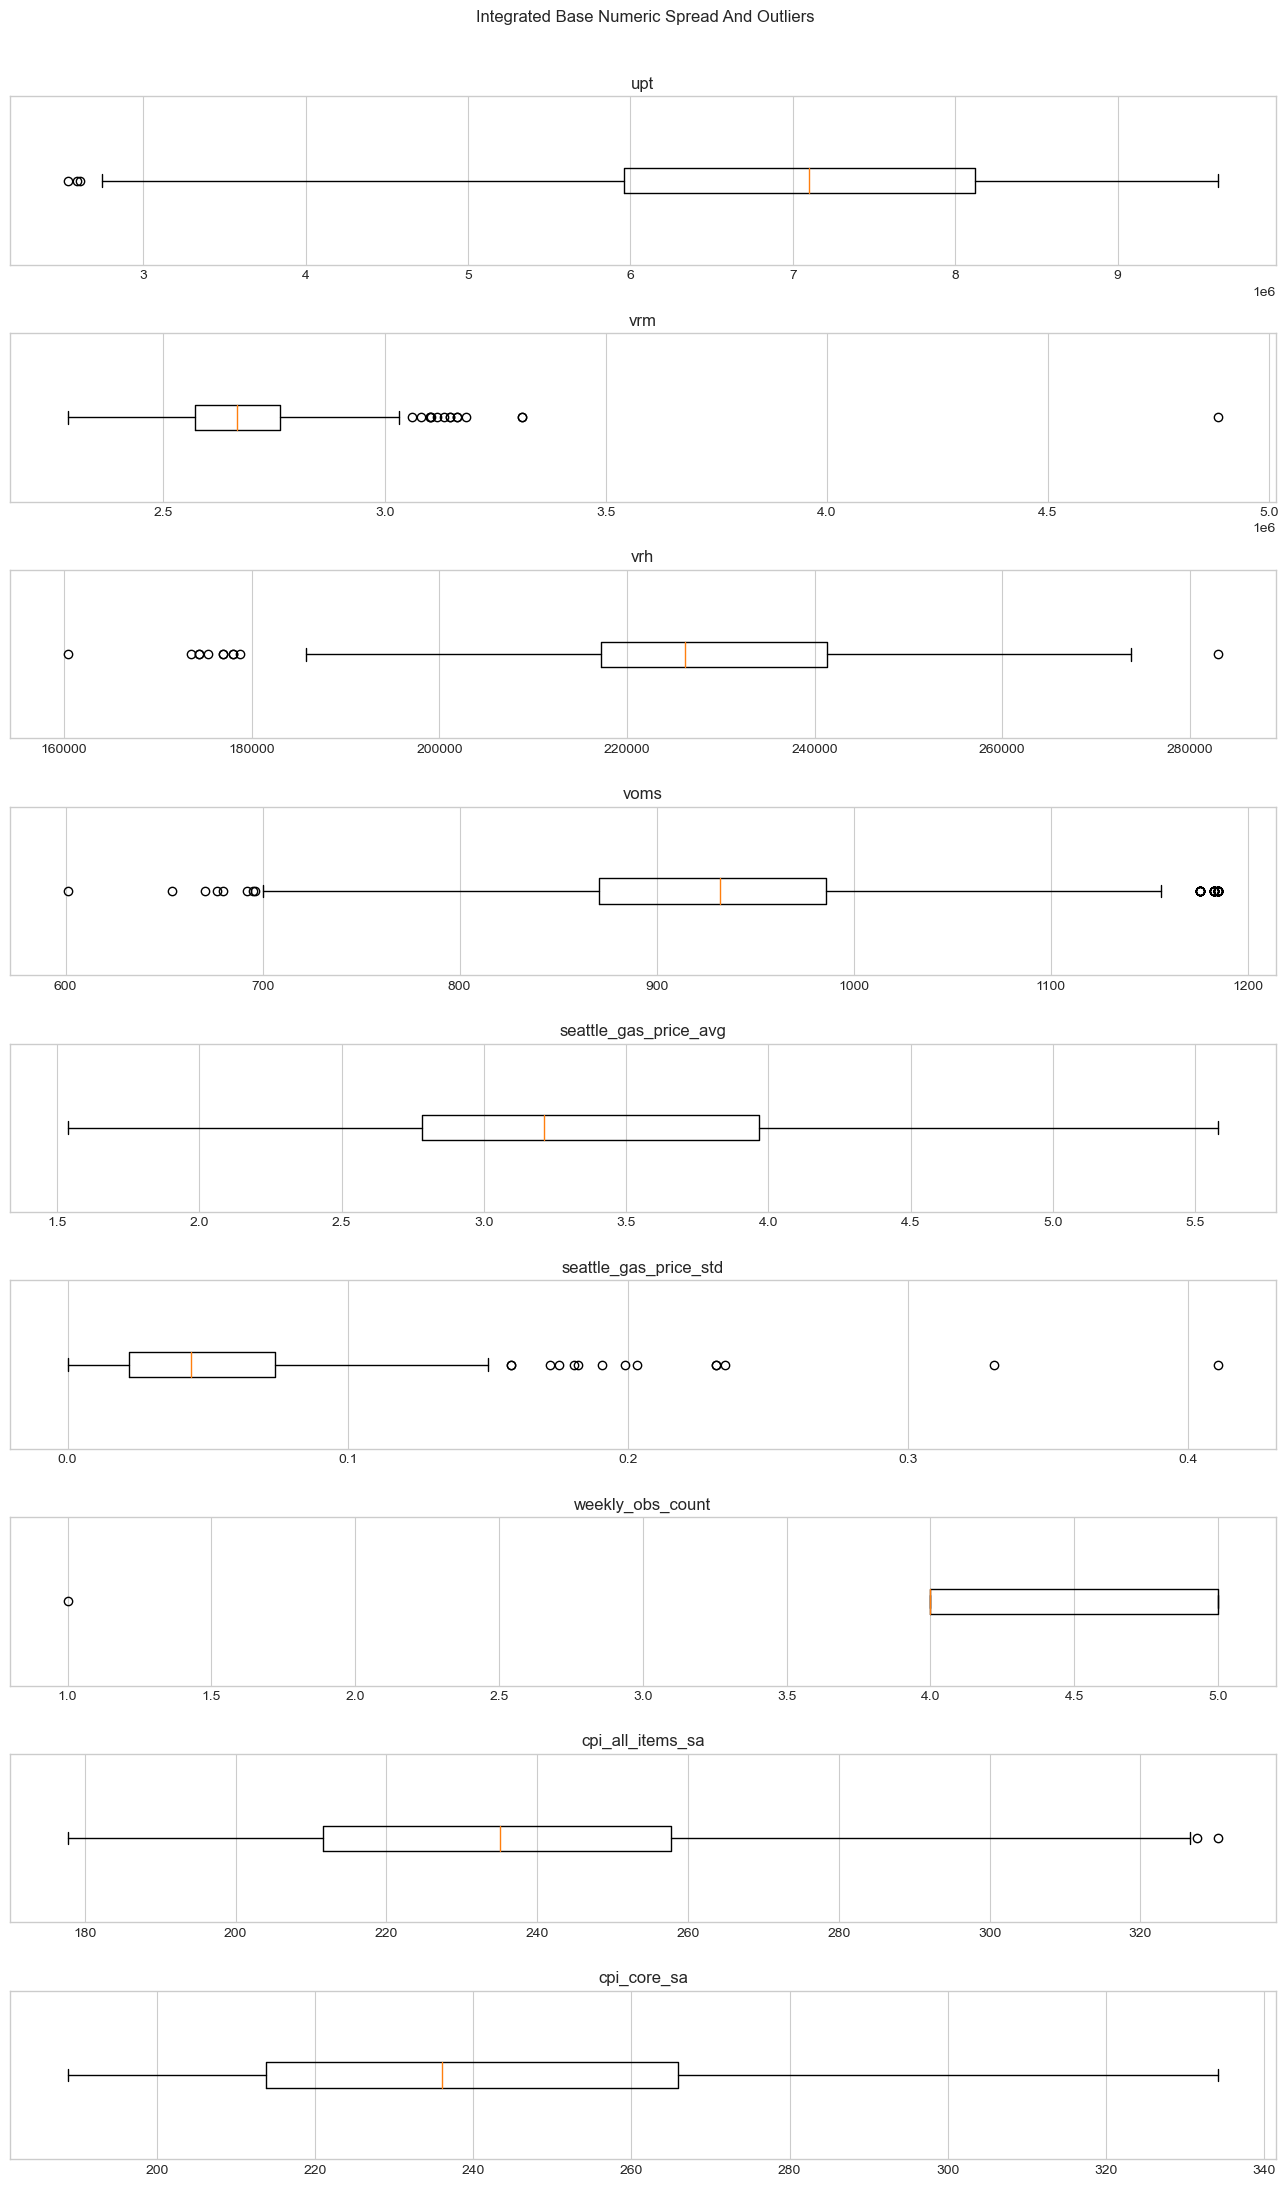

In [9]:
if numeric_cols:
    fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(13, max(3, 2.4 * len(numeric_cols))), sharex=False)
    axes = np.atleast_1d(axes)

    for ax, col in zip(axes, numeric_cols):
        ax.boxplot(df[col].dropna(), vert=False)
        ax.set_title(col)
        ax.set_yticks([])
        ax.set_xlabel("")

    fig.suptitle("Integrated Base Numeric Spread And Outliers", y=1.01)
    plt.tight_layout()


## Time Series Shape


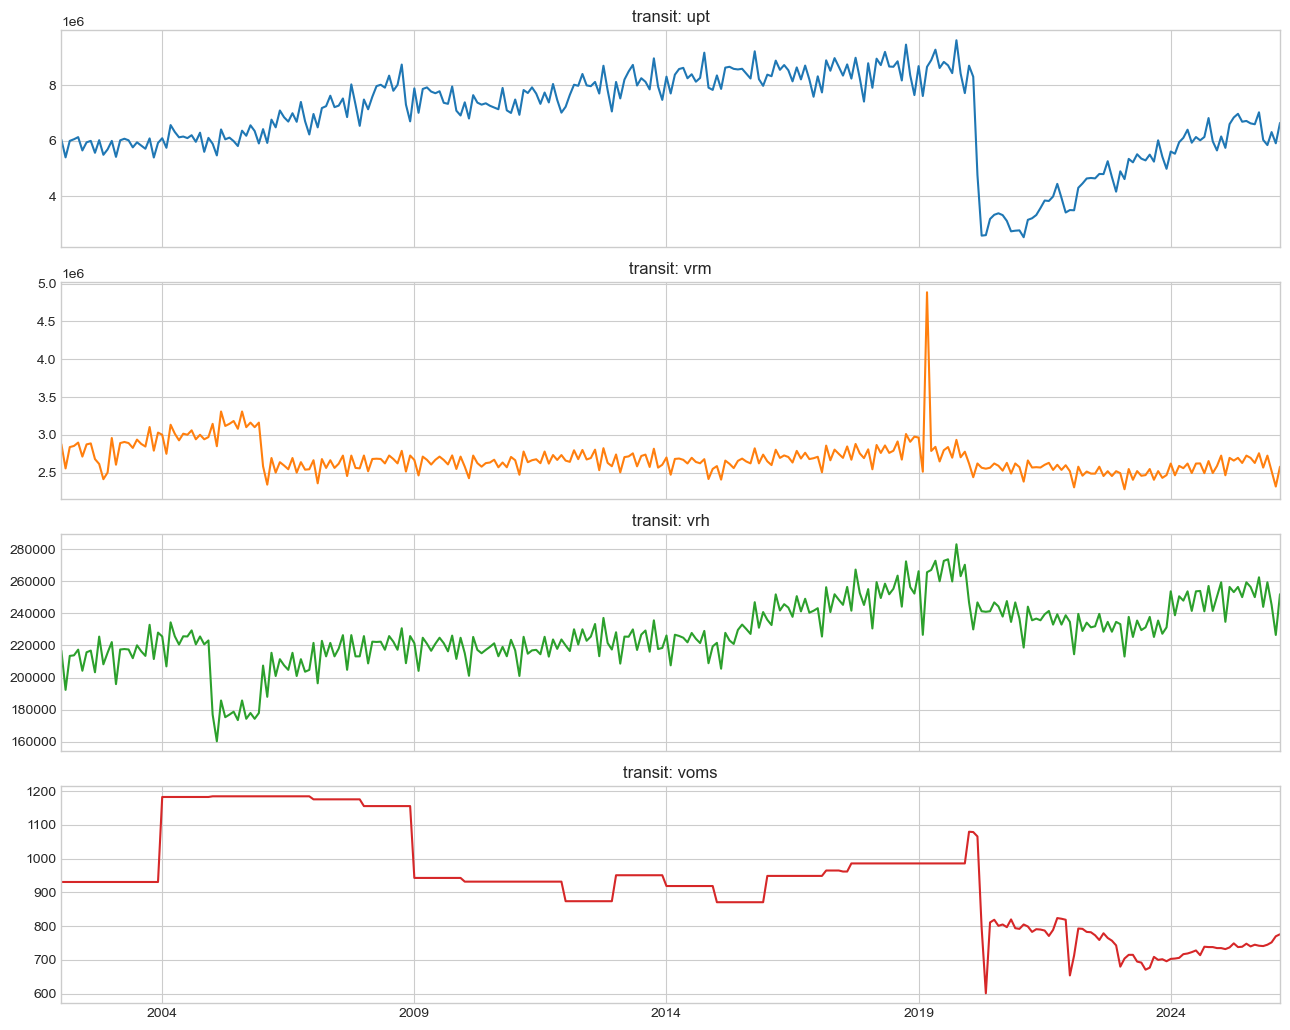

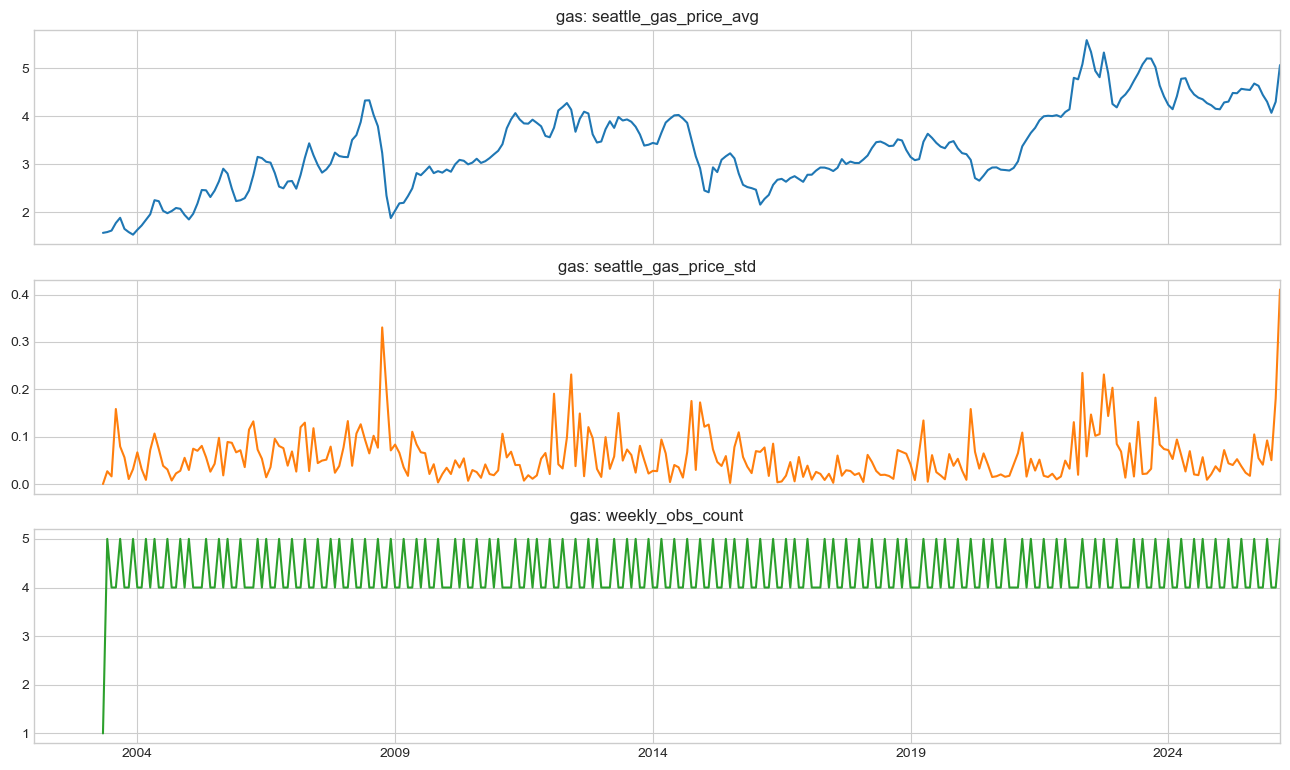

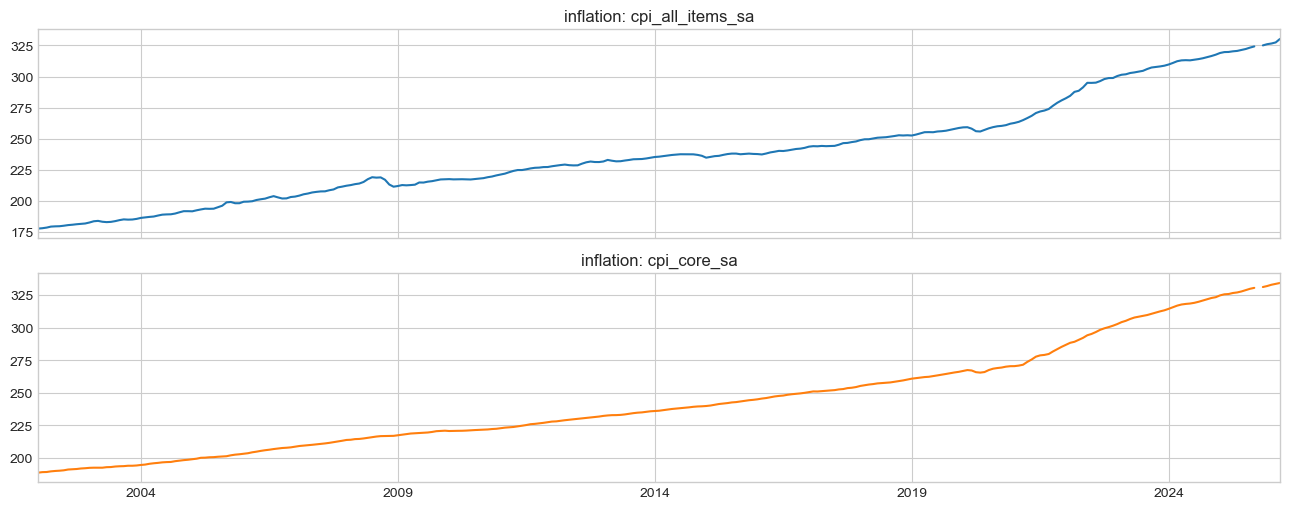

In [10]:
for group_name, cols in source_groups.items():
    cols = [c for c in cols if c in numeric_cols]
    if not cols:
        continue

    ax = df.set_index("date")[cols].plot(subplots=True, figsize=(13, 2.6 * len(cols)), legend=False)
    axes = np.atleast_1d(ax)
    for axis, col in zip(axes, cols):
        axis.set_title(f"{group_name}: {col}")
        axis.set_xlabel("")
    plt.tight_layout()
    plt.show()


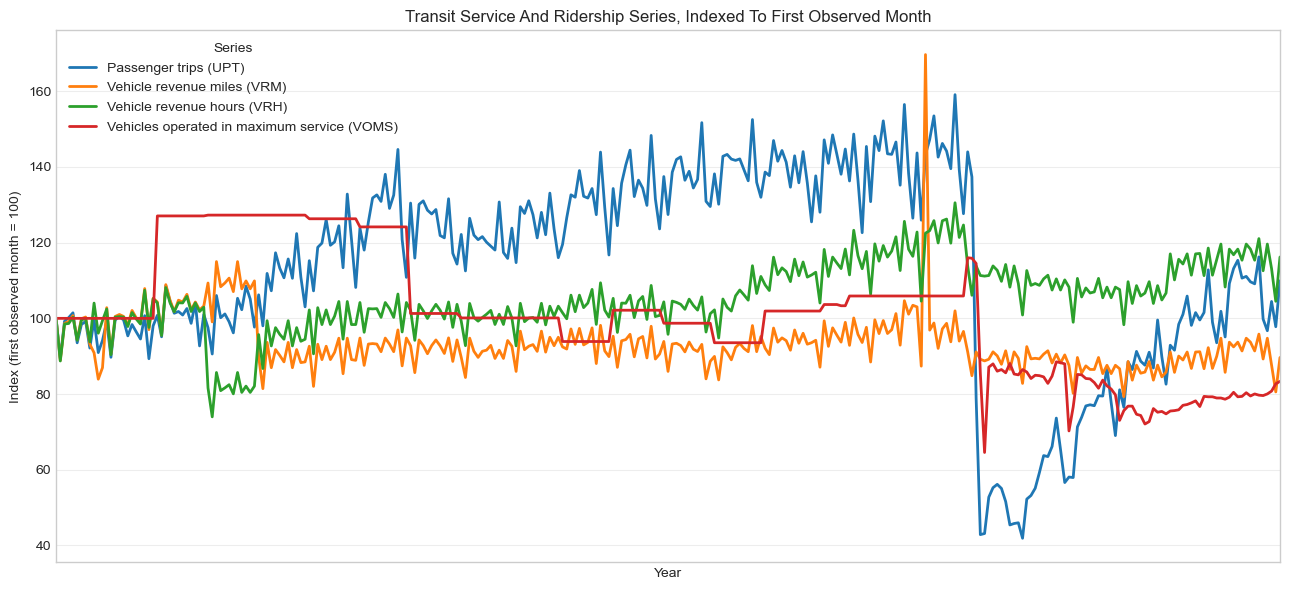

In [11]:
import matplotlib.dates as mdates

transit_overlay_cols = [c for c in ["upt", "vrm", "vrh", "voms"] if c in numeric_cols]

if transit_overlay_cols:
    transit_indexed = df.set_index("date")[transit_overlay_cols].copy()
    transit_indexed = transit_indexed.divide(transit_indexed.bfill().iloc[0]).multiply(100)

    label_map = {
        "upt": "Passenger trips (UPT)",
        "vrm": "Vehicle revenue miles (VRM)",
        "vrh": "Vehicle revenue hours (VRH)",
        "voms": "Vehicles operated in maximum service (VOMS)",
    }

    ax = transit_indexed.rename(columns=label_map).plot(figsize=(13, 6), linewidth=2)
    ax.set_title("Transit Service And Ridership Series, Indexed To First Observed Month")
    ax.set_xlabel("Year")
    ax.set_ylabel("Index (first observed month = 100)")
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.YearLocator(1))
    ax.grid(True, which="major", axis="both", alpha=0.35)
    ax.grid(True, which="minor", axis="x", alpha=0.15)
    ax.legend(title="Series", loc="best")
    plt.tight_layout()
    plt.show()


## Pre-2020 Month-Over-Month Change By Calendar Month

This view uses observations through December 2019 to summarize ordinary pre-COVID monthly movement. It calculates the direct month-over-month percent change for each numeric column, then averages those changes by calendar month.

Some support fields, especially `seattle_gas_price_std` and `weekly_obs_count`, can show very large percent changes because their prior-month values can be small. Those values are still useful diagnostics, but they should be interpreted differently from level metrics such as UPT, service miles/hours, gas price level, and CPI.


In [12]:
PRE_COVID_END = pd.Timestamp("2019-12-01")
pre_covid = df.loc[df["date"] <= PRE_COVID_END, ["date", *numeric_cols]].copy()
pre_covid = pre_covid.sort_values("date").reset_index(drop=True)

mom_pct = pre_covid.set_index("date")[numeric_cols].pct_change(fill_method=None) * 100
mom_pct = mom_pct.replace([np.inf, -np.inf], np.nan)
mom_pct["month"] = mom_pct.index.month

avg_mom_pct_by_month = mom_pct.groupby("month")[numeric_cols].mean().reindex(range(1, 13))
median_mom_pct_by_month = mom_pct.groupby("month")[numeric_cols].median().reindex(range(1, 13))

month_labels = pd.Index(pd.date_range("2000-01-01", periods=12, freq="MS").strftime("%b"), name="month")
avg_mom_pct_by_month.index = month_labels
median_mom_pct_by_month.index = month_labels

avg_mom_pct_by_month.round(2)


,upt,vrm,vrh,voms,seattle_gas_price_avg,seattle_gas_price_std,weekly_obs_count,cpi_all_items_sa,cpi_core_sa
month,,,,,,,,,
Jan,9.070,1.020,1.110,0.480,-0.010,37.900,2.190,0.200,0.190
Feb,-6.840,-8.260,-8.300,0.000,1.030,87.310,-7.190,0.240,0.160
Mar,11.270,15.740,11.430,0.090,7.330,170.940,8.120,0.200,0.170
Apr,-0.640,-5.150,-2.770,0.000,5.320,52.610,0.310,0.200,0.150
May,2.100,1.140,1.350,0.000,5.720,57.080,4.690,0.160,0.150
Jun,-3.500,-1.620,-1.410,0.000,0.320,140.500,21.180,0.210,0.150
Jul,0.130,1.240,1.380,-0.020,-1.520,-11.910,4.410,0.220,0.160
Aug,1.000,2.240,1.940,0.000,0.310,419.870,2.060,0.230,0.160
Sep,-3.510,-4.980,-4.790,0.140,0.420,4.770,-0.880,0.230,0.160


In [13]:
mom_diagnostics = []
levels = pre_covid.set_index("date")[numeric_cols]
for col in numeric_cols:
    prior_values = levels[col].shift(1).abs().dropna()
    changes = mom_pct[col].dropna()
    mom_diagnostics.append(
        {
            "column": col,
            "prior_abs_p05": prior_values.quantile(0.05) if len(prior_values) else np.nan,
            "max_abs_mom_pct": changes.abs().max() if len(changes) else np.nan,
            "mean_abs_mom_pct": changes.abs().mean() if len(changes) else np.nan,
            "median_abs_mom_pct": changes.abs().median() if len(changes) else np.nan,
        }
    )

mom_diagnostics = pd.DataFrame(mom_diagnostics).sort_values("max_abs_mom_pct", ascending=False)
mom_diagnostics


,column,prior_abs_p05,max_abs_mom_pct,mean_abs_mom_pct,median_abs_mom_pct
5,seattle_gas_price_std,0.007,3183.434,155.490,60.312
6,weekly_obs_count,4.000,400.000,17.613,20.000
1,vrm,2503023.000,94.234,5.478,3.959
4,seattle_gas_price_avg,1.852,27.424,4.727,3.271
3,voms,871.000,27.068,0.402,0.000
2,vrh,185769.000,20.696,4.847,3.837
0,upt,5761691.700,18.586,6.194,5.478
7,cpi_all_items_sa,181.710,1.771,0.260,0.223
8,cpi_core_sa,192.040,0.351,0.161,0.164


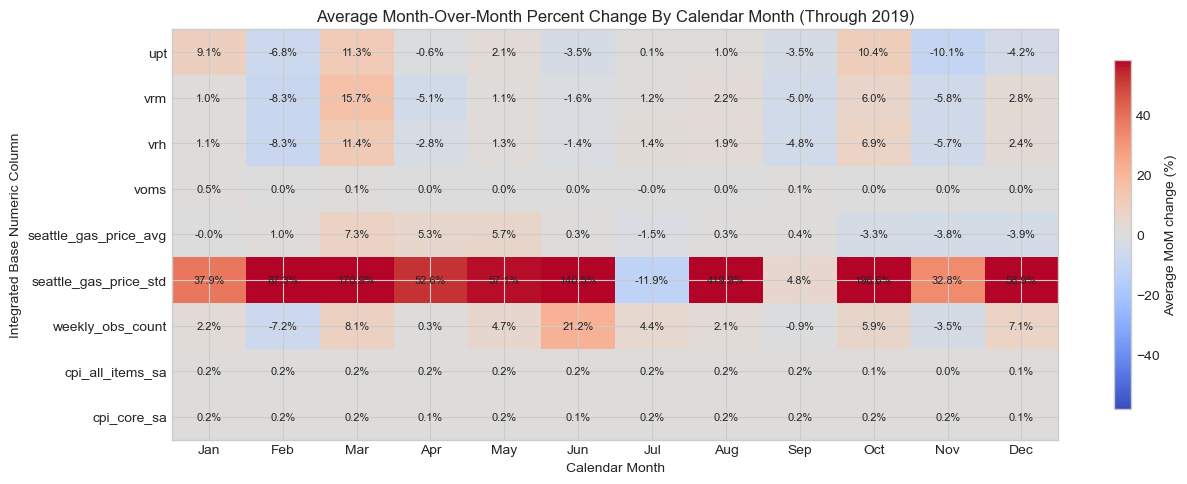

In [14]:
if not avg_mom_pct_by_month.empty:
    heatmap_data = avg_mom_pct_by_month.T
    finite_values = heatmap_data.to_numpy(dtype=float)
    finite_values = finite_values[np.isfinite(finite_values)]
    color_limit = np.nanpercentile(np.abs(finite_values), 95) if finite_values.size else 1
    color_limit = max(color_limit, 1)

    fig, ax = plt.subplots(figsize=(13, max(4, 0.55 * len(heatmap_data))))
    image = ax.imshow(heatmap_data, aspect="auto", cmap="coolwarm", vmin=-color_limit, vmax=color_limit)

    ax.set_title("Average Month-Over-Month Percent Change By Calendar Month (Through 2019)")
    ax.set_xlabel("Calendar Month")
    ax.set_ylabel("Integrated Base Numeric Column")
    ax.set_xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
    ax.set_yticks(range(len(heatmap_data.index)), heatmap_data.index)

    for row in range(heatmap_data.shape[0]):
        for col in range(heatmap_data.shape[1]):
            value = heatmap_data.iloc[row, col]
            if pd.notna(value):
                ax.text(col, row, f"{value:.1f}%", ha="center", va="center", fontsize=8)

    cbar = fig.colorbar(image, ax=ax, shrink=0.85)
    cbar.set_label("Average MoM change (%)")
    plt.tight_layout()


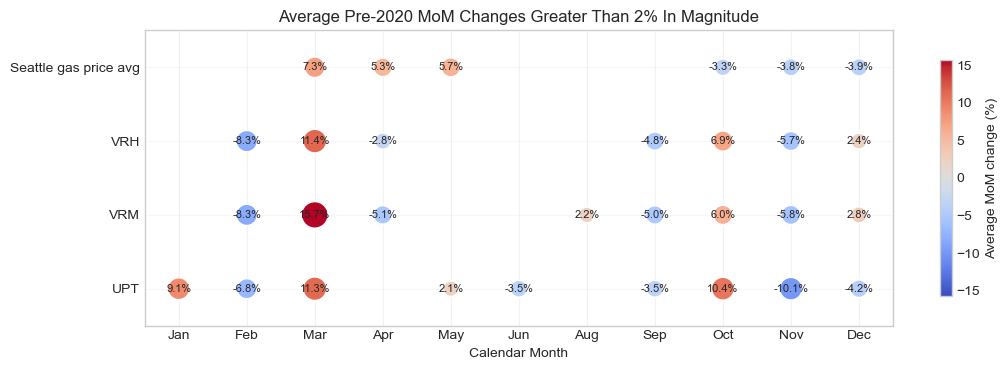

In [15]:
callout_cols = [c for c in ["upt", "vrm", "vrh", "seattle_gas_price_avg"] if c in avg_mom_pct_by_month.columns]
callout_threshold = 2.0

if callout_cols:
    callout_data = avg_mom_pct_by_month[callout_cols].where(lambda x: x.abs() > callout_threshold)
    callout_data = callout_data.dropna(axis=0, how="all")

    if not callout_data.empty:
        label_map = {
            "upt": "UPT",
            "vrm": "VRM",
            "vrh": "VRH",
            "seattle_gas_price_avg": "Seattle gas price avg",
        }
        plot_data = callout_data.rename(columns=label_map)
        long_data = (
            plot_data.rename_axis("month")
            .reset_index()
            .melt(id_vars="month", var_name="series", value_name="avg_mom_pct")
            .dropna(subset=["avg_mom_pct"])
        )

        month_positions = {month: i for i, month in enumerate(plot_data.index)}
        series_order = list(plot_data.columns)
        series_positions = {series: i for i, series in enumerate(series_order)}
        color_limit = max(callout_threshold, long_data["avg_mom_pct"].abs().max())

        fig, ax = plt.subplots(figsize=(11, 3.8))
        scatter = ax.scatter(
            long_data["month"].map(month_positions),
            long_data["series"].map(series_positions),
            s=90 + long_data["avg_mom_pct"].abs() * 18,
            c=long_data["avg_mom_pct"],
            cmap="coolwarm",
            vmin=-color_limit,
            vmax=color_limit,
            edgecolor="white",
            linewidth=1.2,
        )

        for _, row in long_data.iterrows():
            ax.text(
                month_positions[row["month"]],
                series_positions[row["series"]],
                f"{row['avg_mom_pct']:.1f}%",
                ha="center",
                va="center",
                fontsize=8,
            )

        ax.set_title("Average Pre-2020 MoM Changes Greater Than 2% In Magnitude")
        ax.set_xlabel("Calendar Month")
        ax.set_ylabel("")
        ax.set_xticks(range(len(plot_data.index)), plot_data.index)
        ax.set_yticks(range(len(series_order)), series_order)
        ax.set_xlim(-0.5, len(plot_data.index) - 0.5)
        ax.set_ylim(-0.5, len(series_order) - 0.5)
        ax.grid(True, axis="x", alpha=0.25)
        ax.grid(True, axis="y", alpha=0.15)

        cbar = fig.colorbar(scatter, ax=ax, shrink=0.8)
        cbar.set_label("Average MoM change (%)")
        plt.tight_layout()
        plt.show()


In [16]:
mom_mean_median_comparison = pd.concat(
    {
        "mean": avg_mom_pct_by_month,
        "median": median_mom_pct_by_month,
    },
    axis=1,
)

mom_mean_median_comparison.round(2)


mean                                             \
          upt    vrm    vrh   voms seattle_gas_price_avg   
month                                                      
Jan     9.070  1.020  1.110  0.480                -0.010   
Feb    -6.840 -8.260 -8.300  0.000                 1.030   
Mar    11.270 15.740 11.430  0.090                 7.330   
Apr    -0.640 -5.150 -2.770  0.000                 5.320   
May     2.100  1.140  1.350  0.000                 5.720   
Jun    -3.500 -1.620 -1.410  0.000                 0.320   
Jul     0.130  1.240  1.380 -0.020                -1.520   
Aug     1.000  2.240  1.940  0.000                 0.310   
Sep    -3.510 -4.980 -4.790  0.140                 0.420   
Oct    10.360  5.960  6.950  0.000                -3.260   
Nov   -10.070 -5.760 -5.710  0.000                -3.780   
Dec    -4.160  2.810  2.400  0.000                -3.890   

                                                                           \
      seattle_gas_price_std weekly_obs_count cpi_all_items_sa cpi_core_sa   
month                                                                       
Jan                  37.900            2.190            0.200       0.190   
Feb                  87.310           -7.190            0.240       0.160   
Mar                 170.940            8.120            0.200       0.170   
Apr                  52.610            0.310            0.200       0.150   
May                  57.080            4.690            0.160       0.150   
Jun                 140.500           21.180            0.210       0.150   
Jul                 -11.910            4.410            0.220       0.160   
Aug                 419.870            2.060            0.230       0.160   
Sep                   4.770           -0.880            0.230       0.160   
Oct                 196.580            5.880            0.100       0.180   
Nov                  32.770           -3.530            0.030       0.160   
Dec                  58.900            7.060            0.090       0.140   

       median                                                                  \
          upt    vrm    vrh  voms seattle_gas_price_avg seattle_gas_price_std   
month                                                                           
Jan     8.740  0.700  1.000 0.000                 0.520                22.810   
Feb    -7.310 -8.410 -8.240 0.000                 1.010               -11.730   
Mar    11.610 11.680 11.510 0.000                 6.830                 3.950   
Apr    -0.060 -3.720 -3.640 0.000                 4.930                -4.230   
May     1.630  1.110  1.300 0.000                 5.400               -23.880   
Jun    -3.450 -1.890 -1.580 0.000                -0.860               -24.930   
Jul     0.090  1.080  1.410 0.000                -1.140               -40.070   
Aug     1.290  1.730  1.400 0.000                -1.250                57.620   
Sep    -3.600 -5.340 -5.260 0.000                 2.160               -44.370   
Oct     9.900  5.910  7.430 0.000                -3.300               160.710   
Nov   -10.540 -6.270 -6.150 0.000                -1.810               -35.790   
Dec    -6.600  2.380  2.380 0.000                -3.320               -11.720   

                                                     
      weekly_obs_count cpi_all_items_sa cpi_core_sa  
month                                                
Jan              0.000            0.250       0.210  
Feb              0.000            0.250       0.170  
Mar              0.000            0.210       0.180  
Apr              0.000            0.210       0.160  
May              0.000            0.170       0.150  
Jun              0.000            0.120       0.150  
Jul              0.000            0.180       0.150  
Aug              0.000            0.210       0.140  
Sep              0.000            0.200       0.160  
Oct              0.000            0.190       0.180  
Nov              0.000            

In [17]:
avg_mom_pct_long = (
    avg_mom_pct_by_month
    .reset_index()
    .melt(id_vars="month", var_name="column", value_name="avg_mom_pct")
    .dropna()
    .assign(abs_avg_mom_pct=lambda x: x["avg_mom_pct"].abs())
    .sort_values("abs_avg_mom_pct", ascending=False)
)

avg_mom_pct_long.head(20)


,month,column,avg_mom_pct,abs_avg_mom_pct
67,Aug,seattle_gas_price_std,419.866,419.866
69,Oct,seattle_gas_price_std,196.581,196.581
62,Mar,seattle_gas_price_std,170.943,170.943
65,Jun,seattle_gas_price_std,140.499,140.499
61,Feb,seattle_gas_price_std,87.314,87.314
71,Dec,seattle_gas_price_std,58.897,58.897
64,May,seattle_gas_price_std,57.077,57.077
63,Apr,seattle_gas_price_std,52.606,52.606
60,Jan,seattle_gas_price_std,37.902,37.902
70,Nov,seattle_gas_price_std,32.772,32.772


## Full-Series Month-Over-Month Change By Calendar Month

This repeats the same month-over-month percent-change analysis across the full integrated series, including the COVID disruption and recovery period. Comparing this view with the pre-2020 table helps show which source signals changed most once the structural break is included.


In [18]:
full_series = df[["date", *numeric_cols]].sort_values("date").reset_index(drop=True).copy()

full_mom_pct = full_series.set_index("date")[numeric_cols].pct_change(fill_method=None) * 100
full_mom_pct = full_mom_pct.replace([np.inf, -np.inf], np.nan)
full_mom_pct["month"] = full_mom_pct.index.month

full_avg_mom_pct_by_month = full_mom_pct.groupby("month")[numeric_cols].mean().reindex(range(1, 13))
full_median_mom_pct_by_month = full_mom_pct.groupby("month")[numeric_cols].median().reindex(range(1, 13))
full_avg_mom_pct_by_month.index = month_labels
full_median_mom_pct_by_month.index = month_labels

full_avg_mom_pct_by_month.round(2)


,upt,vrm,vrh,voms,seattle_gas_price_avg,seattle_gas_price_std,weekly_obs_count,cpi_all_items_sa,cpi_core_sa
month,,,,,,,,,
Jan,9.030,0.410,0.490,-0.390,-0.430,33.620,2.170,0.240,0.230
Feb,-6.280,-8.130,-8.160,0.650,1.450,75.460,-7.610,0.270,0.200
Mar,10.340,14.060,10.940,0.570,7.220,211.830,10.000,0.250,0.180
Apr,-1.990,-4.620,-2.820,-1.020,4.150,50.350,-1.360,0.180,0.180
May,2.440,1.290,1.460,-1.190,4.720,95.250,5.910,0.190,0.190
Jun,-1.960,-1.650,-1.530,1.460,0.990,140.000,15.220,0.290,0.200
Jul,0.710,1.460,1.600,-0.080,-0.910,-8.590,3.700,0.230,0.200
Aug,0.970,1.920,1.660,-0.340,0.120,302.010,3.040,0.240,0.190
Sep,-2.670,-4.720,-4.570,0.700,0.310,36.210,-1.090,0.260,0.200


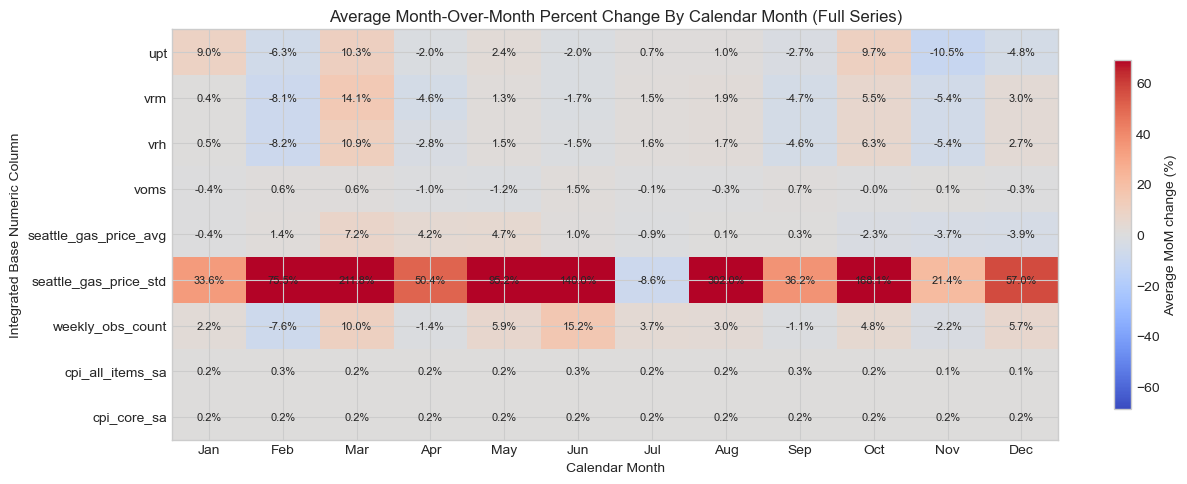

In [19]:
if not full_avg_mom_pct_by_month.empty:
    heatmap_data = full_avg_mom_pct_by_month.T
    finite_values = heatmap_data.to_numpy(dtype=float)
    finite_values = finite_values[np.isfinite(finite_values)]
    color_limit = np.nanpercentile(np.abs(finite_values), 95) if finite_values.size else 1
    color_limit = max(color_limit, 1)

    fig, ax = plt.subplots(figsize=(13, max(4, 0.55 * len(heatmap_data))))
    image = ax.imshow(heatmap_data, aspect="auto", cmap="coolwarm", vmin=-color_limit, vmax=color_limit)

    ax.set_title("Average Month-Over-Month Percent Change By Calendar Month (Full Series)")
    ax.set_xlabel("Calendar Month")
    ax.set_ylabel("Integrated Base Numeric Column")
    ax.set_xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
    ax.set_yticks(range(len(heatmap_data.index)), heatmap_data.index)

    for row in range(heatmap_data.shape[0]):
        for col in range(heatmap_data.shape[1]):
            value = heatmap_data.iloc[row, col]
            if pd.notna(value):
                ax.text(col, row, f"{value:.1f}%", ha="center", va="center", fontsize=8)

    cbar = fig.colorbar(image, ax=ax, shrink=0.85)
    cbar.set_label("Average MoM change (%)")
    plt.tight_layout()


In [20]:
full_vs_pre_covid_mom_delta = full_avg_mom_pct_by_month - avg_mom_pct_by_month
full_vs_pre_covid_mom_delta.round(2)


,upt,vrm,vrh,voms,seattle_gas_price_avg,seattle_gas_price_std,weekly_obs_count,cpi_all_items_sa,cpi_core_sa
month,,,,,,,,,
Jan,-0.030,-0.610,-0.630,-0.860,-0.420,-4.280,-0.010,0.050,0.040
Feb,0.560,0.120,0.140,0.650,0.420,-11.850,-0.420,0.030,0.050
Mar,-0.930,-1.670,-0.490,0.480,-0.110,40.880,1.880,0.050,0.010
Apr,-1.360,0.530,-0.040,-1.020,-1.160,-2.260,-1.680,-0.010,0.040
May,0.330,0.150,0.110,-1.190,-1.000,38.170,1.220,0.040,0.030
Jun,1.540,-0.030,-0.120,1.460,0.670,-0.500,-5.960,0.070,0.050
Jul,0.580,0.220,0.220,-0.070,0.610,3.320,-0.720,0.010,0.040
Aug,-0.030,-0.320,-0.280,-0.340,-0.200,-117.850,0.980,0.010,0.030
Sep,0.840,0.250,0.220,0.560,-0.120,31.440,-0.200,0.030,0.040


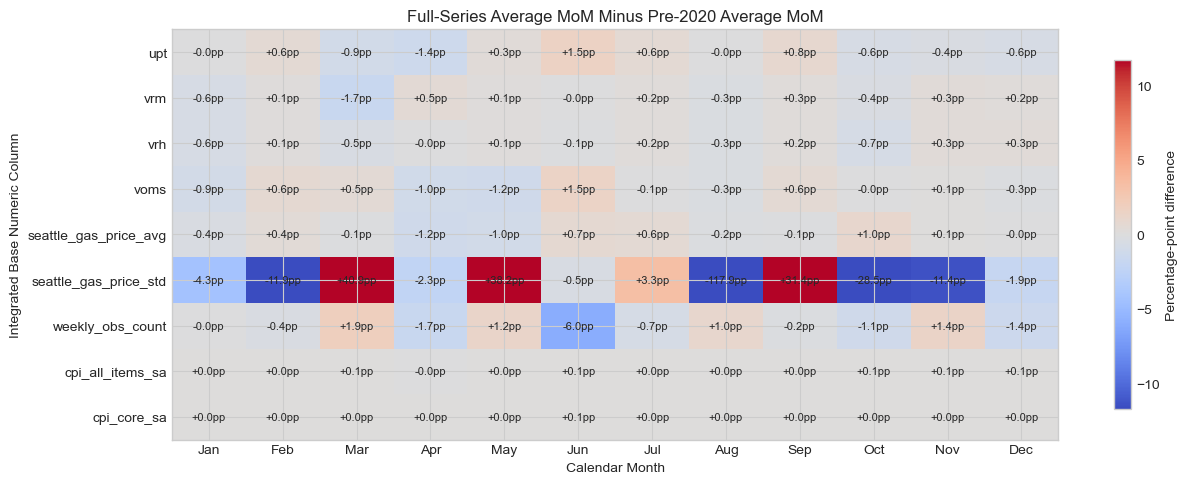

In [21]:
if not full_vs_pre_covid_mom_delta.empty:
    heatmap_data = full_vs_pre_covid_mom_delta.T
    finite_values = heatmap_data.to_numpy(dtype=float)
    finite_values = finite_values[np.isfinite(finite_values)]
    color_limit = np.nanpercentile(np.abs(finite_values), 95) if finite_values.size else 1
    color_limit = max(color_limit, 1)

    fig, ax = plt.subplots(figsize=(13, max(4, 0.55 * len(heatmap_data))))
    image = ax.imshow(heatmap_data, aspect="auto", cmap="coolwarm", vmin=-color_limit, vmax=color_limit)

    ax.set_title("Full-Series Average MoM Minus Pre-2020 Average MoM")
    ax.set_xlabel("Calendar Month")
    ax.set_ylabel("Integrated Base Numeric Column")
    ax.set_xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
    ax.set_yticks(range(len(heatmap_data.index)), heatmap_data.index)

    for row in range(heatmap_data.shape[0]):
        for col in range(heatmap_data.shape[1]):
            value = heatmap_data.iloc[row, col]
            if pd.notna(value):
                ax.text(col, row, f"{value:+.1f}pp", ha="center", va="center", fontsize=8)

    cbar = fig.colorbar(image, ax=ax, shrink=0.85)
    cbar.set_label("Percentage-point difference")
    plt.tight_layout()


In [22]:
full_mom_mean_median_comparison = pd.concat(
    {
        "full_mean": full_avg_mom_pct_by_month,
        "full_median": full_median_mom_pct_by_month,
        "pre_2020_mean": avg_mom_pct_by_month,
        "delta_full_minus_pre_2020": full_vs_pre_covid_mom_delta,
    },
    axis=1,
)

full_mom_mean_median_comparison.round(2)


full_mean                                             \
            upt    vrm    vrh   voms seattle_gas_price_avg   
month                                                        
Jan       9.030  0.410  0.490 -0.390                -0.430   
Feb      -6.280 -8.130 -8.160  0.650                 1.450   
Mar      10.340 14.060 10.940  0.570                 7.220   
Apr      -1.990 -4.620 -2.820 -1.020                 4.150   
May       2.440  1.290  1.460 -1.190                 4.720   
Jun      -1.960 -1.650 -1.530  1.460                 0.990   
Jul       0.710  1.460  1.600 -0.080                -0.910   
Aug       0.970  1.920  1.660 -0.340                 0.120   
Sep      -2.670 -4.720 -4.570  0.700                 0.310   
Oct       9.720  5.520  6.270 -0.010                -2.290   
Nov     -10.480 -5.430 -5.410  0.070                -3.690   
Dec      -4.800  3.010  2.720 -0.250                -3.930   

                                                                           \
      seattle_gas_price_std weekly_obs_count cpi_all_items_sa cpi_core_sa   
month                                                                       
Jan                  33.620            2.170            0.240       0.230   
Feb                  75.460           -7.610            0.270       0.200   
Mar                 211.830           10.000            0.250       0.180   
Apr                  50.350           -1.360            0.180       0.180   
May                  95.250            5.910            0.190       0.190   
Jun                 140.000           15.220            0.290       0.200   
Jul                  -8.590            3.700            0.230       0.200   
Aug                 302.010            3.040            0.240       0.190   
Sep                  36.210           -1.090            0.260       0.200   
Oct                 168.120            4.780            0.170       0.220   
Nov                  21.360           -2.170            0.100       0.200   
Dec                  57.010            5.650            0.150       0.180   

      full_median                                            \
              upt    vrm    vrh  voms seattle_gas_price_avg   
month                                                         
Jan         8.810 -0.680  0.030 0.000                -0.040   
Feb        -6.980 -8.390 -8.220 0.000                 1.960   
Mar        12.350 11.310 11.210 0.000                 6.820   
Apr         0.530 -3.660 -3.530 0.000                 4.190   
May         2.310  1.280  1.450 0.000                 3.780   
Jun        -3.150 -1.890 -1.580 0.000                 0.400   
Jul         0.350  1.270  1.520 0.000                -0.310   
Aug         1.250  1.450  1.070 0.000                -0.570   
Sep        -3.050 -4.830 -4.820 0.000                 0.240   
Oct        10.160  4.810  5.120 0.000                -1.690   
Nov       -10.900 -5.660 -5.850 0.000                -1.810   
Dec        -6.600  2.510  2.680 0.000                -3.200   

                                                                           \
      seattle_gas_price_std weekly_obs_count cpi_all_items_sa cpi_core_sa   
month                                                                       
Jan                  17.330            0.000            0.260       0.210   
Feb                 -18.930            0.000            0.270       0.200   
Mar                  66.400            0.000            0.210       0.190   
Apr                 -18.880            0.000            0.220       0.190   
May                 -23.880            0.000            0.150       0.150   
Jun                 -24.930            0.000            0.230       0.160   
Jul                 -36.560            0.000            0.190       0.190   
Aug                  -2.750            0.000            0.260       0.200   
Sep                 -24.690            0.000            0.240       0.190   
Oct                  97.300            0.000     

In [23]:
full_vs_pre_covid_mom_delta_long = (
    full_vs_pre_covid_mom_delta
    .reset_index()
    .melt(id_vars="month", var_name="column", value_name="delta_pp")
    .dropna()
    .assign(abs_delta_pp=lambda x: x["delta_pp"].abs())
    .sort_values("abs_delta_pp", ascending=False)
)

full_vs_pre_covid_mom_delta_long.head(25)


,month,column,delta_pp,abs_delta_pp
67,Aug,seattle_gas_price_std,-117.851,117.851
62,Mar,seattle_gas_price_std,40.882,40.882
64,May,seattle_gas_price_std,38.170,38.170
68,Sep,seattle_gas_price_std,31.440,31.440
69,Oct,seattle_gas_price_std,-28.459,28.459
61,Feb,seattle_gas_price_std,-11.851,11.851
70,Nov,seattle_gas_price_std,-11.414,11.414
77,Jun,weekly_obs_count,-5.959,5.959
60,Jan,seattle_gas_price_std,-4.284,4.284
66,Jul,seattle_gas_price_std,3.321,3.321


## Correlation


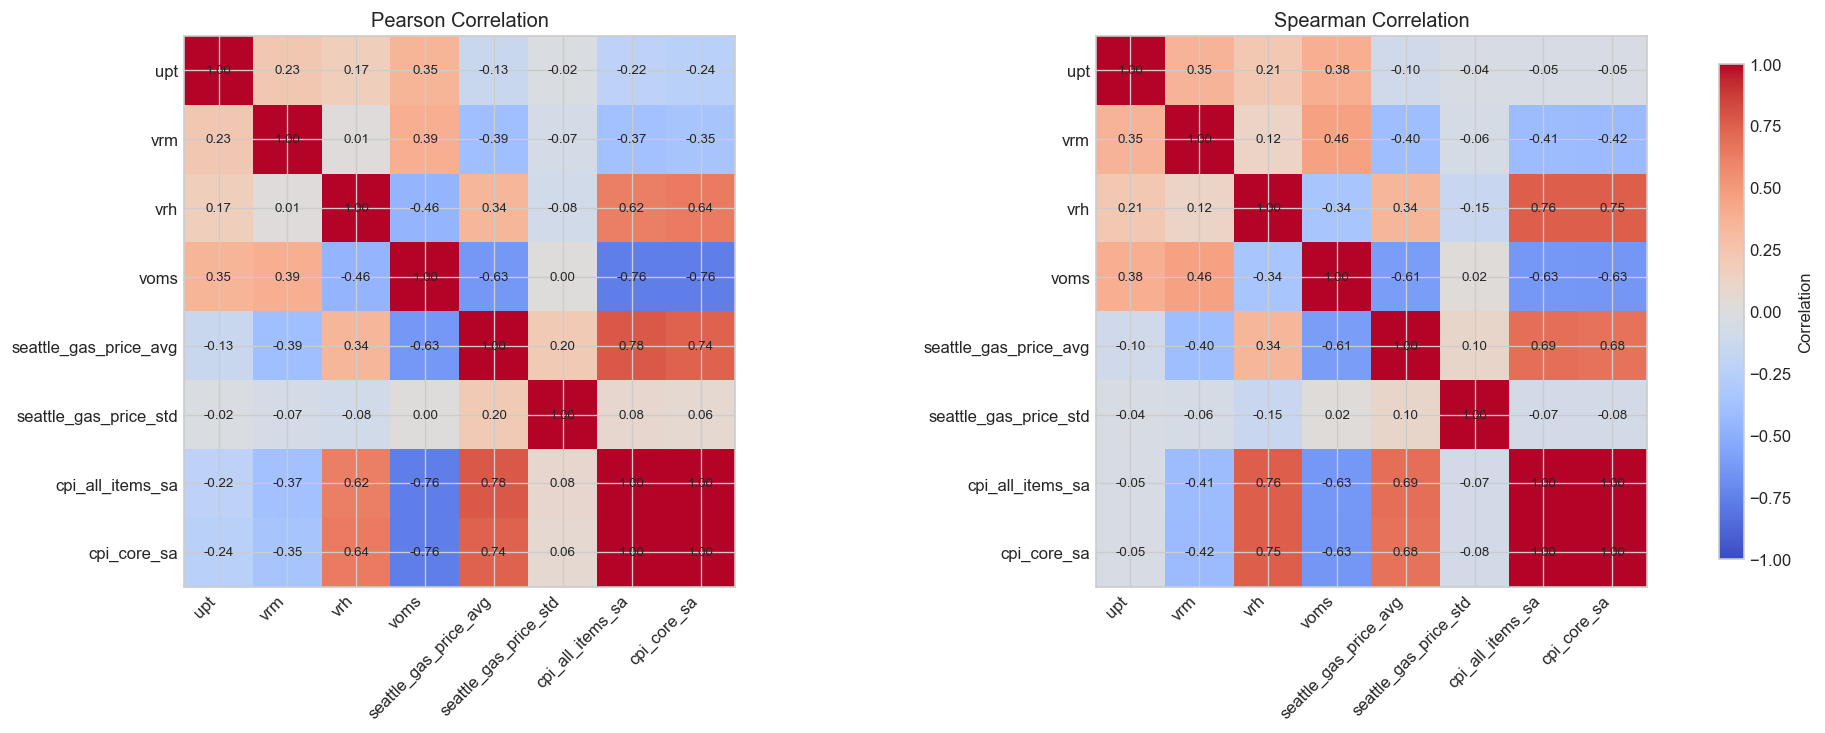

In [1]:
correlation_cols = [col for col in numeric_cols if col != "weekly_obs_count"]
corr = df[correlation_cols].corr(method="pearson")
corr_spearman = df[correlation_cols].corr(method="spearman")

def plot_corr_heatmap(matrix: pd.DataFrame, title: str, ax: plt.Axes) -> None:
    image = ax.imshow(matrix, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_title(title)
    ax.set_xticks(range(len(matrix.columns)), matrix.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(matrix.index)), matrix.index)
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            value = matrix.iloc[row, col]
            ax.text(col, row, f"{value:.2f}", ha="center", va="center", fontsize=8)
    return image

fig, axes = plt.subplots(1, 2, figsize=(16.5, 6), constrained_layout=True)
image = plot_corr_heatmap(corr, "Pearson Correlation", axes[0])
plot_corr_heatmap(corr_spearman, "Spearman Correlation", axes[1])
colorbar = fig.colorbar(image, ax=axes, location="right", fraction=0.035, pad=0.04, shrink=0.9)
colorbar.set_label("Correlation")




In [2]:
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename("pearson_corr")
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
)
corr_pairs["abs_corr"] = corr_pairs["pearson_corr"].abs()
corr_pairs.sort_values("abs_corr", ascending=False).head(20)


,feature_a,feature_b,pearson_corr,abs_corr
27,cpi_all_items_sa,cpi_core_sa,0.997,0.997
23,seattle_gas_price_avg,cpi_all_items_sa,0.780,0.780
21,voms,cpi_core_sa,-0.765,0.765
20,voms,cpi_all_items_sa,-0.760,0.760
24,seattle_gas_price_avg,cpi_core_sa,0.737,0.737
17,vrh,cpi_core_sa,0.639,0.639
18,voms,seattle_gas_price_avg,-0.630,0.630
16,vrh,cpi_all_items_sa,0.619,0.619
13,vrh,voms,-0.460,0.460
8,vrm,voms,0.390,0.390


## Trend-Adjusted And Change-Based Correlation

Raw level correlations can overstate relationships when multiple series share long-run time effects. This section compares several transformations before correlating the series:

- First differences: monthly unit changes.
- Month-over-month percent changes: monthly relative changes.
- Year-over-year percent changes: relative changes compared with the same month one year earlier.
- Seasonal differences: unit changes compared with the same month one year earlier.
- Trend + month residuals: what remains after removing a simple linear time trend and calendar-month effects.

These are EDA views, not proof of stationarity or causality. They help separate shared trend from more local co-movement.


In [3]:
correlation_cols = [col for col in numeric_cols if col != "weekly_obs_count"]
correlation_base = df[["date", *correlation_cols]].sort_values("date").reset_index(drop=True).copy()
correlation_base = correlation_base.set_index("date")
level_data = correlation_base[correlation_cols]

transformed_correlation_inputs = {
    "levels": level_data,
    "first_diff": level_data.diff(),
    "mom_pct_change": level_data.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan),
    "yoy_pct_change": level_data.pct_change(periods=12, fill_method=None).replace([np.inf, -np.inf], np.nan),
    "seasonal_diff_12m": level_data.diff(12),
}

{key: value.dropna(how="all").shape for key, value in transformed_correlation_inputs.items()}



{'levels': (291, 8), 'first_diff': (290, 8), 'mom_pct_change': (290, 8), 'yoy_pct_change': (279, 8), 'seasonal_diff_12m': (279, 8)}

In [4]:
def trend_month_residualize(series: pd.Series) -> pd.Series:
    y = pd.to_numeric(series, errors="coerce")
    valid = y.notna()
    if valid.sum() < 24:
        return pd.Series(index=series.index, data=np.nan, name=series.name)

    month_dummies = pd.get_dummies(series.index.month, prefix="month", drop_first=True, dtype=float)
    design = pd.DataFrame(
        {
            "intercept": 1.0,
            "time_index": np.arange(len(series), dtype=float),
        },
        index=series.index,
    )
    design = pd.concat([design, month_dummies.set_index(series.index)], axis=1)
    x = design.loc[valid].to_numpy(dtype=float)
    target = y.loc[valid].to_numpy(dtype=float)
    beta, *_ = np.linalg.lstsq(x, target, rcond=None)
    fitted = design.to_numpy(dtype=float) @ beta
    return pd.Series(y.to_numpy(dtype=float) - fitted, index=series.index, name=series.name)

trend_month_residuals = level_data.apply(trend_month_residualize)
transformed_correlation_inputs["trend_month_residual"] = trend_month_residuals
trend_month_residuals.describe().T


,count,mean,std,min,25%,50%,75%,max
upt,291.000,0.000,1526074.014,-4256200.439,-1166157.043,261983.512,1328407.163,2382120.148
vrm,291.000,-0.000,186953.027,-328758.675,-102994.903,-27288.037,68535.527,2097022.263
vrh,291.000,0.000,12662.658,-42505.595,-6710.786,-269.623,7064.734,34684.649
voms,291.000,-0.000,98.820,-228.885,-64.959,-17.100,102.141,237.399
seattle_gas_price_avg,275.000,0.000,0.586,-1.353,-0.448,0.017,0.450,1.416
seattle_gas_price_std,275.000,-0.000,0.051,-0.076,-0.033,-0.013,0.019,0.326
cpi_all_items_sa,290.000,0.000,9.821,-17.629,-9.429,0.588,4.991,23.598
cpi_core_sa,290.000,0.000,9.547,-12.928,-9.077,-1.079,5.406,22.838


In [5]:
def correlation_pair_table(corr_matrix: pd.DataFrame, method_name: str) -> pd.DataFrame:
    pairs = (
        corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        .stack()
        .rename("correlation")
        .reset_index()
        .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
    )
    pairs["method"] = method_name
    pairs["abs_correlation"] = pairs["correlation"].abs()
    return pairs[["method", "feature_a", "feature_b", "correlation", "abs_correlation"]]

transformed_correlations = {
    name: data.corr(method="pearson")
    for name, data in transformed_correlation_inputs.items()
}

transformed_corr_pairs = pd.concat(
    [correlation_pair_table(matrix, name) for name, matrix in transformed_correlations.items()],
    ignore_index=True,
)

transformed_corr_pairs.sort_values(["method", "abs_correlation"], ascending=[True, False]).head(30)


,method,feature_a,feature_b,correlation,abs_correlation
29,first_diff,upt,vrh,0.654,0.654
35,first_diff,vrm,vrh,0.650,0.650
51,first_diff,seattle_gas_price_avg,cpi_all_items_sa,0.648,0.648
55,first_diff,cpi_all_items_sa,cpi_core_sa,0.566,0.566
28,first_diff,upt,vrm,0.443,0.443
31,first_diff,upt,seattle_gas_price_avg,0.259,0.259
33,first_diff,upt,cpi_all_items_sa,0.194,0.194
43,first_diff,vrh,seattle_gas_price_std,0.172,0.172
48,first_diff,voms,cpi_all_items_sa,0.170,0.170
34,first_diff,upt,cpi_core_sa,0.167,0.167


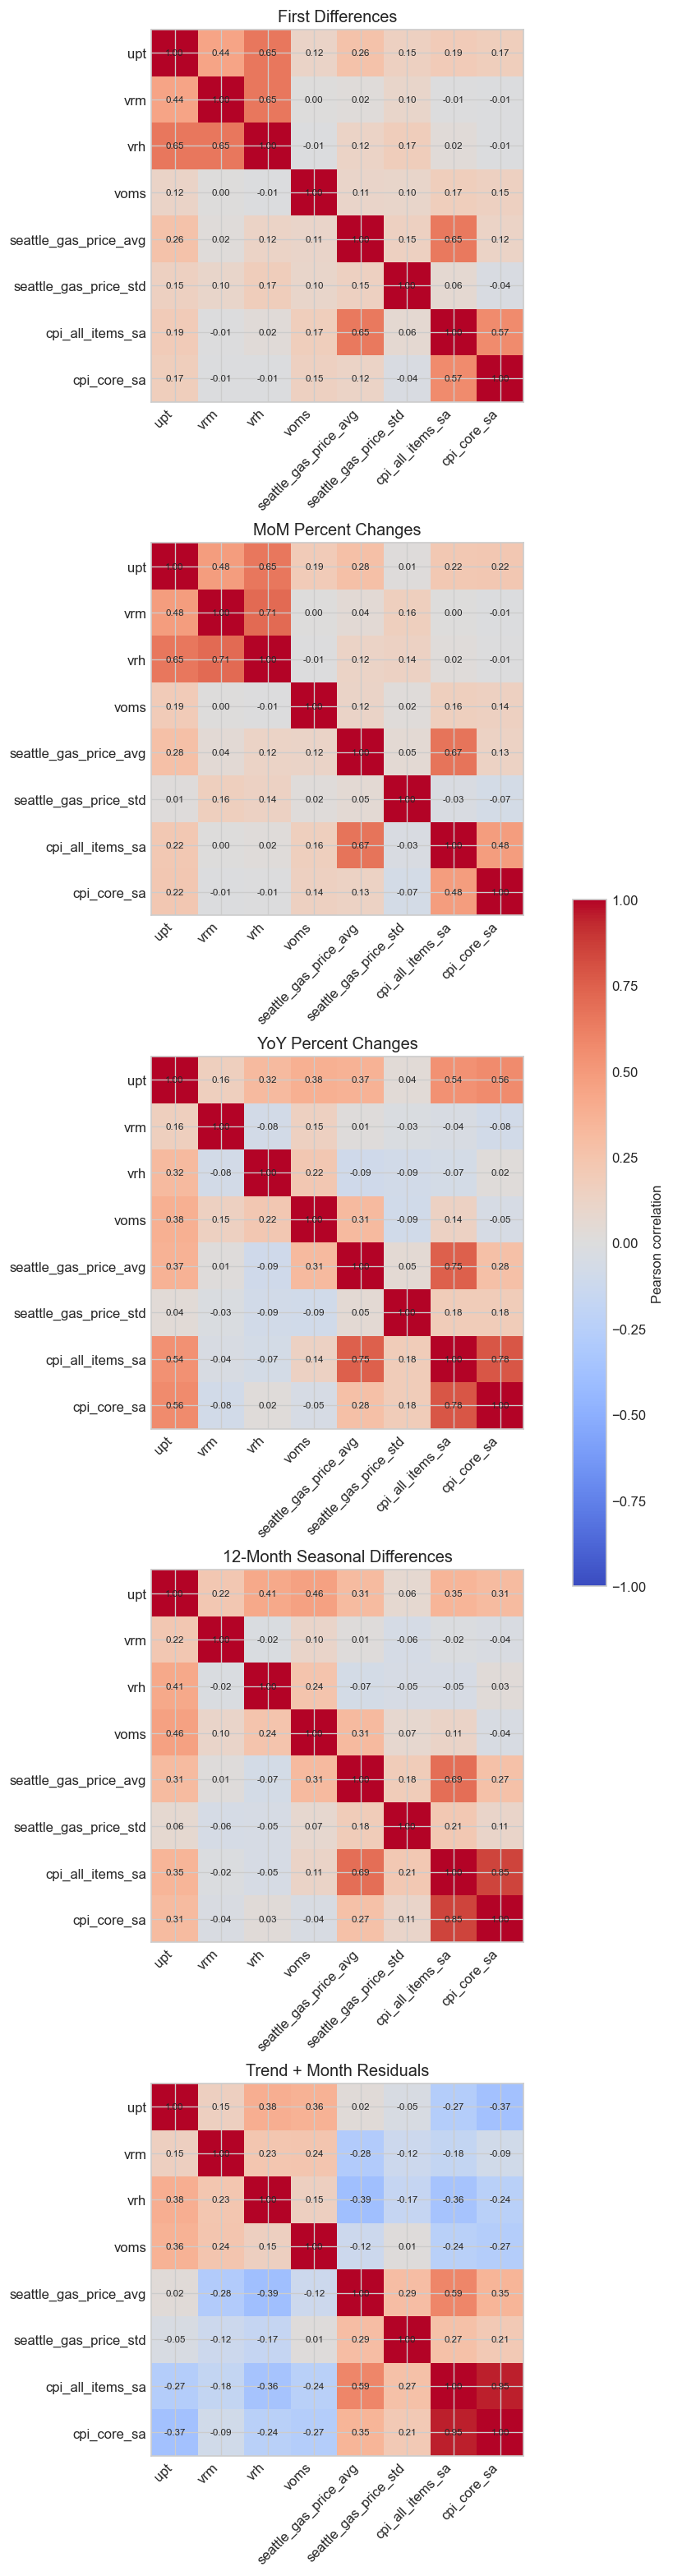

In [6]:
def plot_correlation_matrix(corr_matrix: pd.DataFrame, title: str, ax: plt.Axes) -> None:
    image = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_title(title)
    ax.set_xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr_matrix.index)), corr_matrix.index)
    for row in range(corr_matrix.shape[0]):
        for col in range(corr_matrix.shape[1]):
            value = corr_matrix.iloc[row, col]
            if pd.notna(value):
                ax.text(col, row, f"{value:.2f}", ha="center", va="center", fontsize=7)
    return image

plot_order = [
    ("first_diff", "First Differences"),
    ("mom_pct_change", "MoM Percent Changes"),
    ("yoy_pct_change", "YoY Percent Changes"),
    ("seasonal_diff_12m", "12-Month Seasonal Differences"),
    ("trend_month_residual", "Trend + Month Residuals"),
]

fig, axes = plt.subplots(
    len(plot_order),
    1,
    figsize=(11.5, 5.2 * len(plot_order)),
    constrained_layout=True,
)
axes = np.atleast_1d(axes)
for ax, (key, title) in zip(axes, plot_order):
    image = plot_correlation_matrix(transformed_correlations[key], title, ax)

colorbar = fig.colorbar(
    image,
    ax=axes,
    location="right",
    fraction=0.035,
    pad=0.05,
    shrink=0.9,
)
colorbar.set_label("Pearson correlation")



In [7]:
focus_target = "upt"
focus_methods = ["levels", "first_diff", "mom_pct_change", "yoy_pct_change", "seasonal_diff_12m", "trend_month_residual"]

upt_correlation_comparison = pd.DataFrame(
    {
        method: transformed_correlations[method][focus_target].drop(labels=[focus_target], errors="ignore")
        for method in focus_methods
        if focus_target in transformed_correlations[method].columns
    }
)
upt_correlation_comparison["max_abs_corr_across_methods"] = upt_correlation_comparison.abs().max(axis=1)
upt_correlation_comparison.sort_values("max_abs_corr_across_methods", ascending=False).round(3)


,levels,first_diff,mom_pct_change,yoy_pct_change,seasonal_diff_12m,trend_month_residual,max_abs_corr_across_methods
vrh,0.168,0.654,0.650,0.319,0.414,0.384,0.654
cpi_core_sa,-0.241,0.167,0.225,0.565,0.308,-0.369,0.565
cpi_all_items_sa,-0.219,0.194,0.217,0.535,0.345,-0.272,0.535
vrm,0.226,0.443,0.481,0.161,0.220,0.154,0.481
voms,0.350,0.117,0.194,0.381,0.455,0.363,0.455
seattle_gas_price_avg,-0.135,0.259,0.276,0.365,0.310,0.025,0.365
seattle_gas_price_std,-0.024,0.147,0.011,0.038,0.064,-0.046,0.147


In [8]:
top_transformed_correlations = (
    transformed_corr_pairs
    .query("method != 'levels'")
    .sort_values("abs_correlation", ascending=False)
    .head(25)
)

top_transformed_correlations.round(3)


,method,feature_a,feature_b,correlation,abs_correlation
167,trend_month_residual,cpi_all_items_sa,cpi_core_sa,0.949,0.949
139,seasonal_diff_12m,cpi_all_items_sa,cpi_core_sa,0.849,0.849
111,yoy_pct_change,cpi_all_items_sa,cpi_core_sa,0.783,0.783
107,yoy_pct_change,seattle_gas_price_avg,cpi_all_items_sa,0.747,0.747
63,mom_pct_change,vrm,vrh,0.711,0.711
135,seasonal_diff_12m,seattle_gas_price_avg,cpi_all_items_sa,0.694,0.694
79,mom_pct_change,seattle_gas_price_avg,cpi_all_items_sa,0.666,0.666
29,first_diff,upt,vrh,0.654,0.654
35,first_diff,vrm,vrh,0.650,0.650
57,mom_pct_change,upt,vrh,0.650,0.650


### Spearman Rank Correlation Robustness Check

Pearson correlation measures linear co-movement in the transformed values. Spearman correlation is rank-based, so it is less sensitive to outliers and can flag monotonic relationships that are not strictly linear. This is useful as a robustness check for the same transformed views, especially around COVID-era shocks or variables with occasional jumps.


In [1]:
spearman_transformed_correlations = {
    name: data.corr(method="spearman")
    for name, data in transformed_correlation_inputs.items()
}

spearman_transformed_corr_pairs = pd.concat(
    [correlation_pair_table(matrix, name) for name, matrix in spearman_transformed_correlations.items()],
    ignore_index=True,
).rename(columns={"correlation": "spearman_correlation", "abs_correlation": "abs_spearman_correlation"})

spearman_transformed_corr_pairs.sort_values(
    ["method", "abs_spearman_correlation"], ascending=[True, False]
).head(30).round(3)


,method,feature_a,feature_b,spearman_correlation,abs_spearman_correlation
35,first_diff,vrm,vrh,0.935,0.935
29,first_diff,upt,vrh,0.733,0.733
28,first_diff,upt,vrm,0.693,0.693
51,first_diff,seattle_gas_price_avg,cpi_all_items_sa,0.546,0.546
55,first_diff,cpi_all_items_sa,cpi_core_sa,0.454,0.454
31,first_diff,upt,seattle_gas_price_avg,0.223,0.223
32,first_diff,upt,seattle_gas_price_std,0.156,0.156
43,first_diff,vrh,seattle_gas_price_std,0.143,0.143
34,first_diff,upt,cpi_core_sa,0.126,0.126
38,first_diff,vrm,seattle_gas_price_std,0.120,0.120


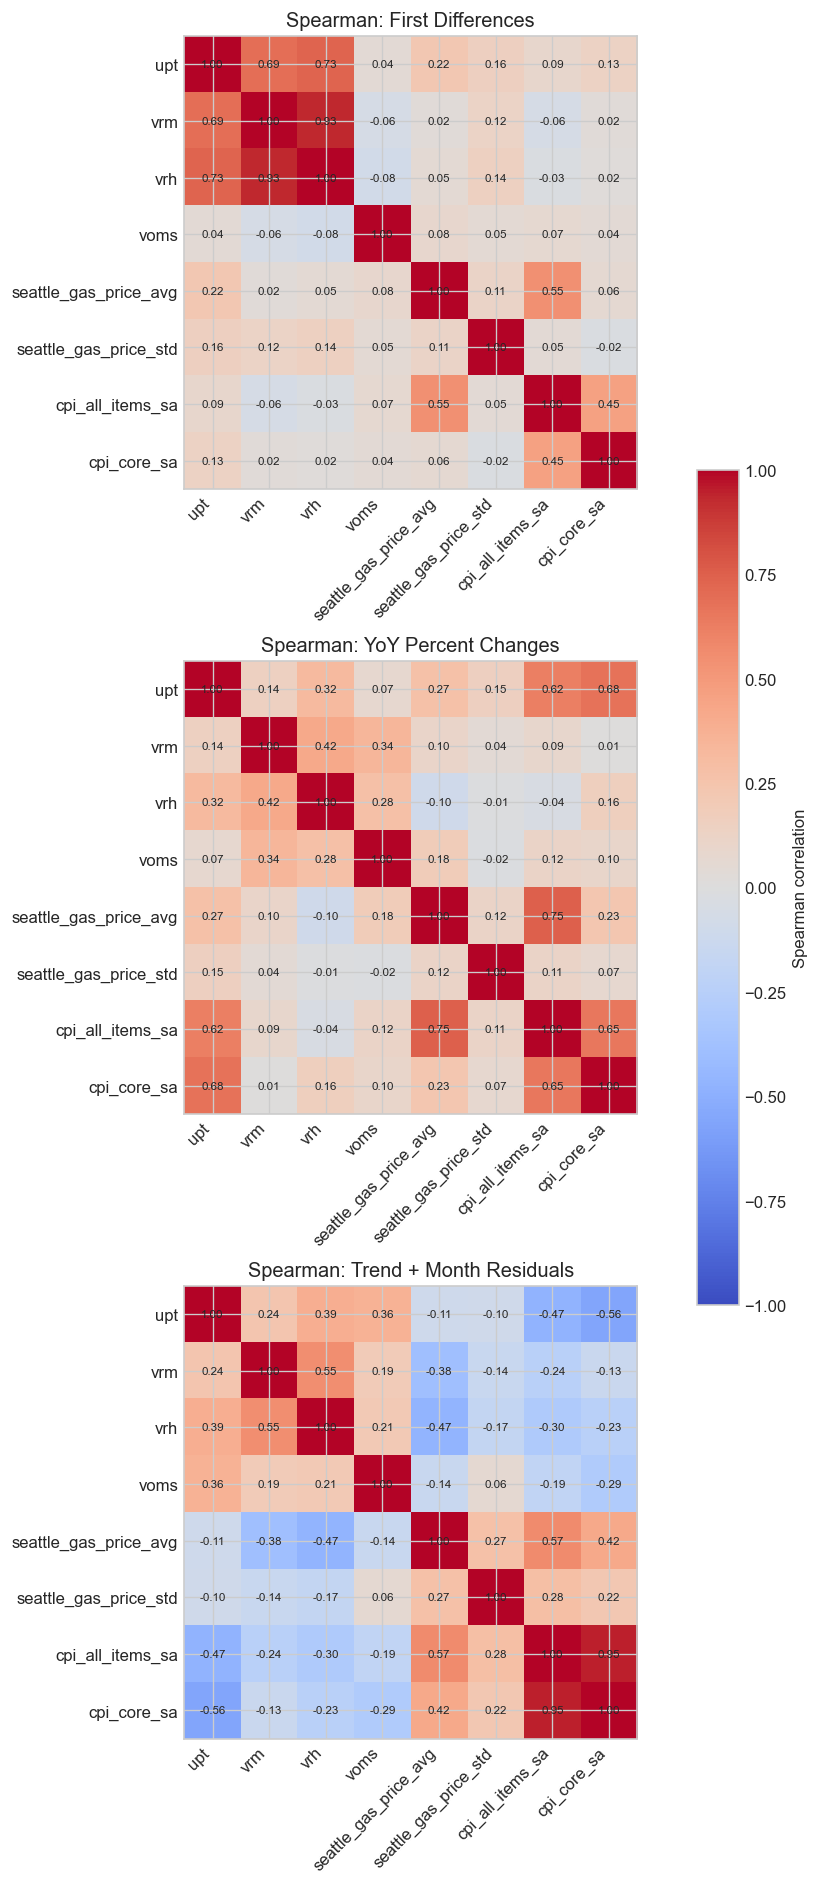

In [2]:
spearman_plot_order = [
    ("first_diff", "First Differences"),
    ("yoy_pct_change", "YoY Percent Changes"),
    ("trend_month_residual", "Trend + Month Residuals"),
]

fig, axes = plt.subplots(
    len(spearman_plot_order),
    1,
    figsize=(11.5, 5.2 * len(spearman_plot_order)),
    constrained_layout=True,
)
axes = np.atleast_1d(axes)
for ax, (key, title) in zip(axes, spearman_plot_order):
    image = plot_correlation_matrix(spearman_transformed_correlations[key], f"Spearman: {title}", ax)

colorbar = fig.colorbar(
    image,
    ax=axes,
    location="right",
    fraction=0.035,
    pad=0.05,
    shrink=0.9,
)
colorbar.set_label("Spearman correlation")


In [3]:
pearson_pair_lookup = transformed_corr_pairs.rename(
    columns={"correlation": "pearson_correlation", "abs_correlation": "abs_pearson_correlation"}
)

pearson_vs_spearman = pearson_pair_lookup.merge(
    spearman_transformed_corr_pairs,
    on=["method", "feature_a", "feature_b"],
    how="inner",
)
pearson_vs_spearman["correlation_delta"] = (
    pearson_vs_spearman["spearman_correlation"] - pearson_vs_spearman["pearson_correlation"]
)
pearson_vs_spearman["abs_correlation_delta"] = pearson_vs_spearman["correlation_delta"].abs()

pearson_vs_spearman.sort_values("abs_correlation_delta", ascending=False).head(25).round(3)


,method,feature_a,feature_b,pearson_correlation,abs_pearson_correlation,spearman_correlation,abs_spearman_correlation,correlation_delta,abs_correlation_delta
91,yoy_pct_change,vrm,vrh,-0.077,0.077,0.416,0.416,0.493,0.493
119,seasonal_diff_12m,vrm,vrh,-0.024,0.024,0.403,0.403,0.428,0.428
114,seasonal_diff_12m,upt,voms,0.455,0.455,0.068,0.068,-0.387,0.387
147,trend_month_residual,vrm,vrh,0.227,0.227,0.553,0.553,0.326,0.326
86,yoy_pct_change,upt,voms,0.381,0.381,0.072,0.072,-0.309,0.309
35,first_diff,vrm,vrh,0.650,0.650,0.935,0.935,0.285,0.285
117,seasonal_diff_12m,upt,cpi_all_items_sa,0.345,0.345,0.616,0.616,0.271,0.271
28,first_diff,upt,vrm,0.443,0.443,0.693,0.693,0.249,0.249
118,seasonal_diff_12m,upt,cpi_core_sa,0.308,0.308,0.556,0.556,0.249,0.249
63,mom_pct_change,vrm,vrh,0.711,0.711,0.939,0.939,0.229,0.229


**Spearman takeaway:** use Spearman as a robustness check rather than the dashboard default. If Pearson and Spearman agree, the transformed relationship is less likely to be driven by one or two extreme values. If they diverge, that pair deserves visual inspection before becoming a dashboard claim.


## Beyond Correlation: Statistical Test Starters

This section starts to move beyond pairwise correlation while keeping the interpretation appropriately observational. The goal is not to claim causality; it is to test whether relationships remain visible after accounting for time-series structure, lagging, repeated seasonality, and the COVID-era structural break.


In [1]:
import warnings

import statsmodels.api as sm
from scipy import stats
from statsmodels.tsa.stattools import adfuller, grangercausalitytests, kpss

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

test_cols = [
    c for c in [
        "upt",
        "vrm",
        "vrh",
        "voms",
        "seattle_gas_price_avg",
        "cpi_all_items_sa",
        "cpi_core_sa",
    ]
    if c in df.columns
]

test_base = df[["date", *test_cols]].sort_values("date").set_index("date")
test_base.head()


,upt,vrm,vrh,voms,seattle_gas_price_avg,cpi_all_items_sa,cpi_core_sa
date,,,,,,,
2002-01-01,6045861.000,2878549.000,216788.000,931.000,NaN,177.700,188.700
2002-02-01,5406135.000,2558164.000,192360.000,931.000,NaN,178.000,189.100
2002-03-01,5999230.000,2840121.000,213519.000,931.000,NaN,178.500,189.200
2002-04-01,6058398.000,2855047.000,213860.000,931.000,NaN,179.300,189.700
2002-05-01,6134503.000,2899399.000,217418.000,931.000,NaN,179.500,190.000


### Stationarity Checks

These tests ask whether each series behaves like a stable process or whether trend/nonstationarity is likely contaminating raw level relationships. The ADF test uses nonstationarity as its null; KPSS uses stationarity as its null. Agreement between the two is more useful than either test alone.


In [2]:
stationarity_inputs = {
    "level": test_base,
    "first_diff": test_base.diff(),
    "yoy_pct_change": test_base.pct_change(periods=12, fill_method=None).replace([np.inf, -np.inf], np.nan),
}

stationarity_rows = []
for transform_name, transform_df in stationarity_inputs.items():
    for col in test_cols:
        series = transform_df[col].dropna()
        if len(series) < 24:
            continue
        adf_p = adfuller(series, autolag="AIC")[1]
        try:
            kpss_p = kpss(series, regression="c", nlags="auto")[1]
        except Exception:
            kpss_p = np.nan
        stationarity_rows.append(
            {
                "transform": transform_name,
                "series": col,
                "n": len(series),
                "adf_p": adf_p,
                "kpss_p": kpss_p,
                "adf_stationary_at_5pct": adf_p < 0.05,
                "kpss_stationary_at_5pct": kpss_p > 0.05 if pd.notna(kpss_p) else np.nan,
            }
        )

stationarity_tests = pd.DataFrame(stationarity_rows)
stationarity_tests.round(4)


,transform,series,n,adf_p,kpss_p,adf_stationary_at_5pct,kpss_stationary_at_5pct
0,level,upt,291,0.163,0.050,False,False
1,level,vrm,291,0.079,0.017,False,False
2,level,vrh,291,0.297,0.010,False,False
3,level,voms,291,0.563,0.010,False,False
4,level,seattle_gas_price_avg,275,0.526,0.010,False,False
5,level,cpi_all_items_sa,290,0.997,0.010,False,False
6,level,cpi_core_sa,290,0.999,0.010,False,False
7,first_diff,upt,290,0.001,0.100,True,True
8,first_diff,vrm,290,0.000,0.100,True,True
9,first_diff,vrh,290,0.000,0.100,True,True


**Stationarity takeaway:** raw levels mostly fail these checks, so level correlations are especially vulnerable to shared time trend. First differences look much more stable for transit/service/gas variables, while YoY percent changes are a strong default for monthly EDA because they reduce both trend and seasonality. CPI core remains harder to stationarize in this simple setup, which is a useful caution before overinterpreting its relationships.


### Lagged Cross-Correlation

This looks at whether transformed predictors lead UPT YoY changes by 0 to 12 months. It is still descriptive, but it starts to separate same-month co-movement from forecasting-useful lead relationships.


In [3]:
upt_yoy = test_base.pct_change(periods=12, fill_method=None).replace([np.inf, -np.inf], np.nan)

lagged_corr_rows = []
for predictor in [c for c in test_cols if c != "upt"]:
    for lag in range(0, 13):
        aligned = pd.concat(
            {
                "upt_yoy": upt_yoy["upt"],
                "predictor_yoy_lagged": upt_yoy[predictor].shift(lag),
            },
            axis=1,
        ).dropna()
        if len(aligned) > 20:
            lagged_corr_rows.append(
                {
                    "predictor": predictor,
                    "lag_months": lag,
                    "corr_with_upt_yoy": aligned["upt_yoy"].corr(aligned["predictor_yoy_lagged"]),
                    "n": len(aligned),
                }
            )

lagged_corr = pd.DataFrame(lagged_corr_rows)
lagged_corr.assign(abs_corr=lambda x: x["corr_with_upt_yoy"].abs()).sort_values(
    "abs_corr", ascending=False
).head(25).round(3)


,predictor,lag_months,corr_with_upt_yoy,n,abs_corr
65,cpi_core_sa,0,0.565,278,0.565
66,cpi_core_sa,1,0.537,277,0.537
52,cpi_all_items_sa,0,0.535,278,0.535
53,cpi_all_items_sa,1,0.530,277,0.530
54,cpi_all_items_sa,2,0.509,276,0.509
67,cpi_core_sa,2,0.507,276,0.507
55,cpi_all_items_sa,3,0.491,275,0.491
68,cpi_core_sa,3,0.487,275,0.487
56,cpi_all_items_sa,4,0.477,274,0.477
69,cpi_core_sa,4,0.469,274,0.469


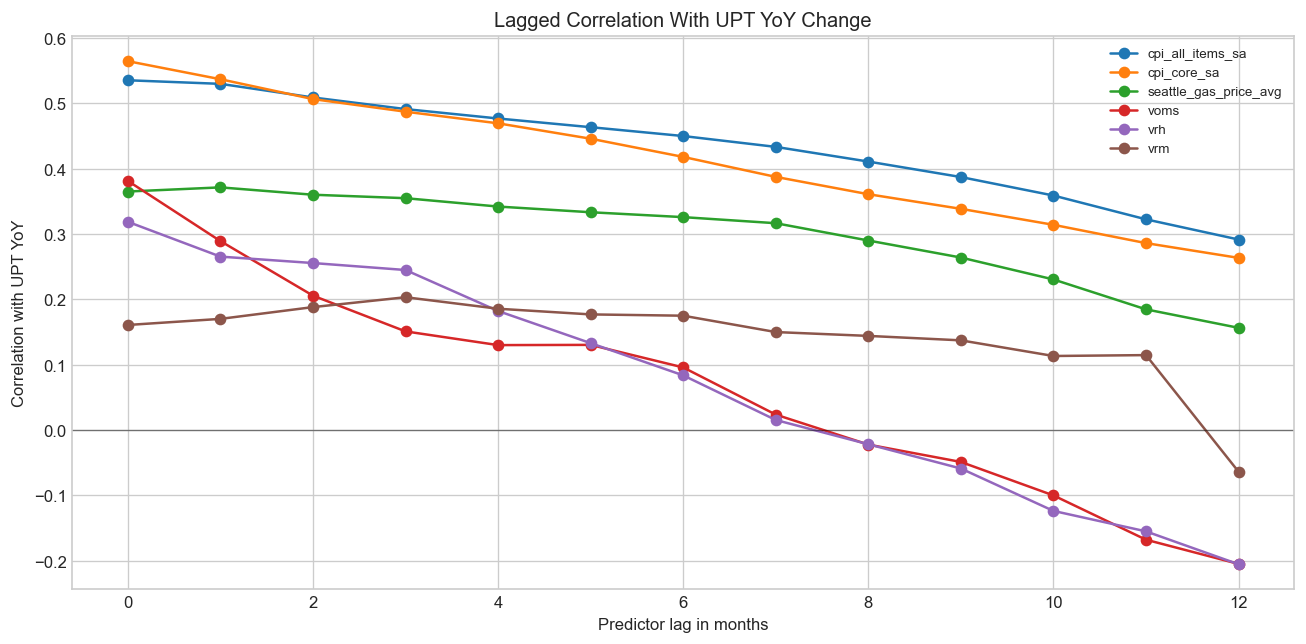

In [4]:
if not lagged_corr.empty:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    for predictor, group in lagged_corr.groupby("predictor"):
        ax.plot(group["lag_months"], group["corr_with_upt_yoy"], marker="o", label=predictor)
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.45)
    ax.set_title("Lagged Correlation With UPT YoY Change")
    ax.set_xlabel("Predictor lag in months")
    ax.set_ylabel("Correlation with UPT YoY")
    ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()


**Lagged-correlation takeaway:** CPI variables show the strongest YoY correlations with UPT in this first pass, especially at short lags. Gas price and VOMS also show moderate relationships, while service variables are less dominant in this YoY-lag view than they were in MoM/first-difference views. This is a good reminder that conclusions depend heavily on the transformation being tested.


### Granger-Style Predictive Tests

Granger tests ask whether past values of a predictor improve prediction of UPT beyond past UPT values. This is predictive evidence, not causal evidence. Here we test YoY percent-change series with lags from 1 to 6 months.


In [5]:
granger_rows = []
for predictor in [c for c in test_cols if c != "upt"]:
    test_df = upt_yoy[["upt", predictor]].dropna()
    if len(test_df) < 40:
        continue
    try:
        result = grangercausalitytests(test_df[["upt", predictor]], maxlag=6, verbose=False)
        pvals = [result[lag][0]["ssr_ftest"][1] for lag in range(1, 7)]
        best_lag = int(np.argmin(pvals) + 1)
        granger_rows.append(
            {
                "predictor": predictor,
                "best_lag": best_lag,
                "min_ssr_ftest_p": min(pvals),
                "pvals_by_lag_1_to_6": ", ".join(f"{p:.3f}" for p in pvals),
            }
        )
    except Exception as exc:
        granger_rows.append(
            {
                "predictor": predictor,
                "best_lag": np.nan,
                "min_ssr_ftest_p": np.nan,
                "pvals_by_lag_1_to_6": str(exc)[:120],
            }
        )

granger_summary = pd.DataFrame(granger_rows).sort_values("min_ssr_ftest_p")
granger_summary.round(4)


,predictor,best_lag,min_ssr_ftest_p,pvals_by_lag_1_to_6
1,vrh,4,0.000,"0.340, 0.002, 0.000, 0.000, 0.000, 0.000"
5,cpi_core_sa,5,0.001,"0.231, 0.256, 0.012, 0.006, 0.001, 0.003"
2,voms,6,0.004,"0.016, 0.087, 0.204, 0.011, 0.007, 0.004"
4,cpi_all_items_sa,3,0.012,"0.038, 0.025, 0.012, 0.021, 0.042, 0.067"
3,seattle_gas_price_avg,1,0.101,"0.101, 0.262, 0.155, 0.204, 0.166, 0.256"
0,vrm,3,0.263,"0.329, 0.381, 0.263, 0.342, 0.534, 0.675"


**Granger takeaway:** in this simple YoY setup, VRH, VOMS, CPI all-items, and CPI core show statistically notable predictive signals for UPT at some lags. VRM and gas price average do not clear the same bar here. This should be treated as a screening result because repeated lag testing can create false positives, and because these tests do not solve omitted-variable or structural-break problems.


### H3 Diagnostic Regression With HAC Standard Errors

This model aligns the explanatory diagnostic with the main forecasting setup by predicting UPT YoY change three months ahead. Predictors are the as-of-month YoY values available at the forecast origin, plus known target-month calendar effects and a post-COVID target-period indicator. HAC/Newey-West standard errors are used because monthly residuals can be autocorrelated.

In [40]:
horizon_months = 3
model_df = upt_yoy.rename(columns={col: f"{col}_yoy" for col in test_cols}).copy()
model_df["target_date"] = model_df.index + pd.DateOffset(months=horizon_months)
model_df["upt_yoy_target_h3"] = model_df["upt_yoy"].shift(-horizon_months)
model_df["target_post_covid"] = (model_df["target_date"] >= pd.Timestamp("2020-03-01")).astype(int)

reg_month_dummies = pd.get_dummies(
    model_df["target_date"].dt.month,
    prefix="target_month",
    drop_first=True,
    dtype=float,
)
reg_month_dummies.index = model_df.index
regression_df = pd.concat([model_df, reg_month_dummies], axis=1).dropna()

y = regression_df["upt_yoy_target_h3"]
h3_regression_terms = [
    "upt_yoy",
    "vrm_yoy",
    "vrh_yoy",
    "voms_yoy",
    "seattle_gas_price_avg_yoy",
    "cpi_all_items_sa_yoy",
    "cpi_core_sa_yoy",
    "target_post_covid",
    *list(reg_month_dummies.columns),
]
h3_regression_terms = [term for term in h3_regression_terms if term in regression_df.columns]
X = sm.add_constant(regression_df[h3_regression_terms])
h3_hac_model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

h3_hac_coef = pd.DataFrame(
    {
        "term": h3_hac_model.params.index,
        "coef": h3_hac_model.params.values,
        "std_err_hac": h3_hac_model.bse.values,
        "p_value_hac": h3_hac_model.pvalues.values,
        "ci_low": h3_hac_model.conf_int()[0].values,
        "ci_high": h3_hac_model.conf_int()[1].values,
    }
)

print(
    f"n={int(h3_hac_model.nobs)}, "
    f"R2={h3_hac_model.rsquared:.3f}, "
    f"adjusted R2={h3_hac_model.rsquared_adj:.3f}"
)
h3_hac_coef.loc[h3_hac_coef["term"].isin(["const", *h3_regression_terms[:8]])].round(4)

n=259, R2=0.601, adjusted R2=0.570


,term,coef,std_err_hac,p_value_hac,ci_low,ci_high
0,const,-0.078,0.049,0.111,-0.174,0.018
1,upt_yoy,0.538,0.113,0.000,0.316,0.759
2,vrm_yoy,0.344,0.222,0.120,-0.090,0.778
3,vrh_yoy,0.279,0.179,0.120,-0.073,0.631
4,voms_yoy,-0.344,0.168,0.040,-0.673,-0.015
5,seattle_gas_price_avg_yoy,0.126,0.121,0.301,-0.112,0.363
6,cpi_all_items_sa_yoy,0.271,1.541,0.860,-2.749,3.291
7,cpi_core_sa_yoy,3.611,3.172,0.255,-2.607,9.828
8,target_post_covid,-0.069,0.084,0.408,-0.234,0.095


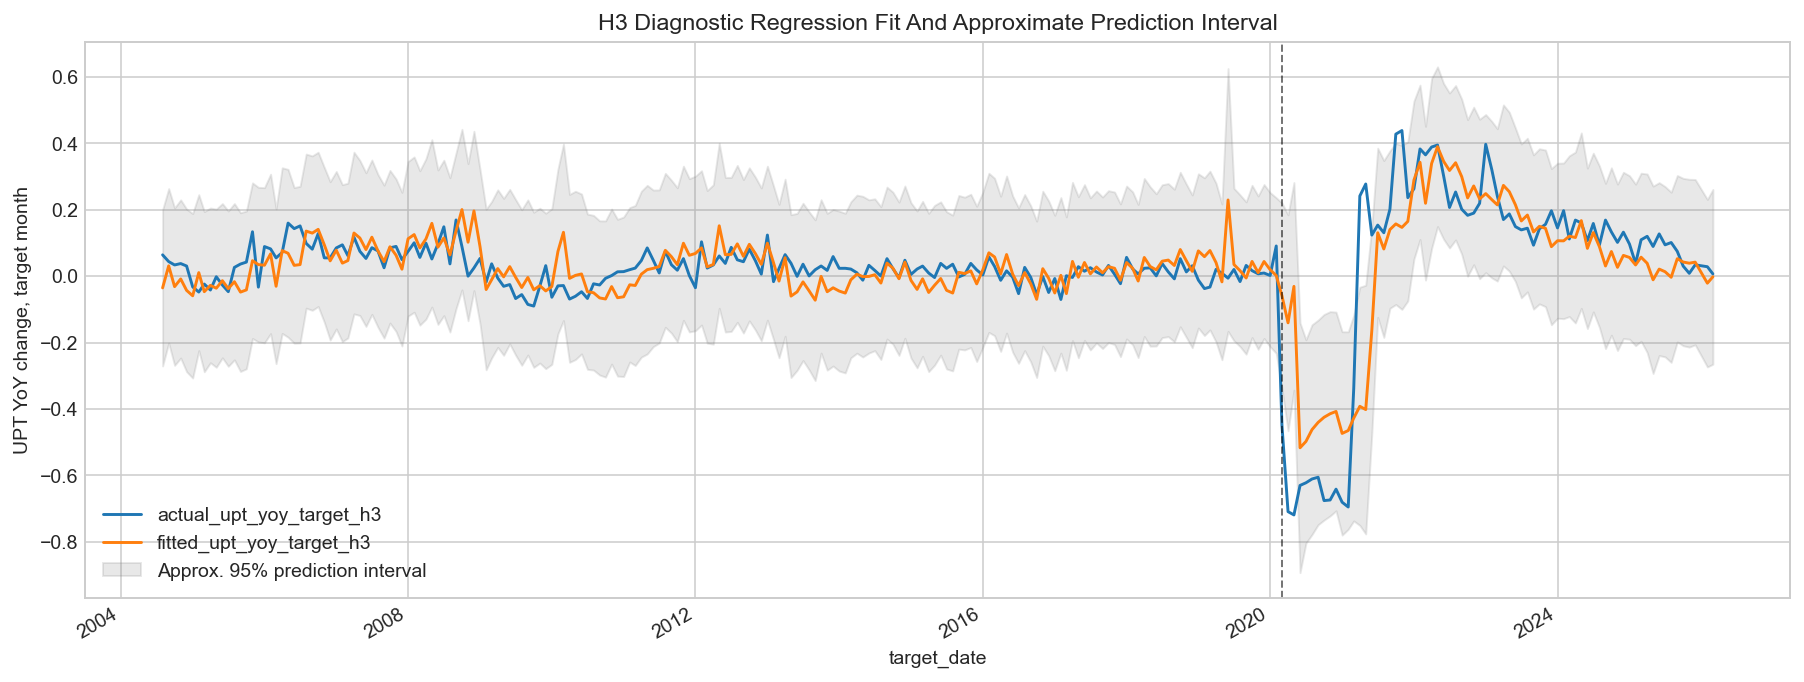

,as_of_date,actual_upt_yoy_target_h3,fitted_upt_yoy_target_h3,mean_ci_low,mean_ci_high,obs_pi_low,obs_pi_high
target_date,,,,,,,
2025-03-01,2024-12-01,0.109,0.057,-0.055,0.169,-0.196,0.310
2025-04-01,2025-01-01,0.120,0.039,-0.106,0.183,-0.230,0.308
2025-05-01,2025-02-01,0.089,-0.011,-0.179,0.157,-0.293,0.271
2025-06-01,2025-03-01,0.127,0.021,-0.106,0.149,-0.239,0.281
2025-07-01,2025-04-01,0.094,0.013,-0.106,0.133,-0.243,0.270
2025-08-01,2025-05-01,0.101,-0.003,-0.122,0.116,-0.260,0.253
2025-09-01,2025-06-01,0.075,0.053,-0.054,0.159,-0.198,0.303
2025-10-01,2025-07-01,0.030,0.043,-0.067,0.152,-0.209,0.295
2025-11-01,2025-08-01,0.008,0.039,-0.072,0.150,-0.214,0.292


In [41]:
h3_predictions = h3_hac_model.get_prediction(X).summary_frame(alpha=0.05)
h3_prediction_view = pd.DataFrame(
    {
        "as_of_date": regression_df.index,
        "target_date": regression_df["target_date"].values,
        "actual_upt_yoy_target_h3": y.values,
        "fitted_upt_yoy_target_h3": h3_predictions["mean"].values,
        "mean_ci_low": h3_predictions["mean_ci_lower"].values,
        "mean_ci_high": h3_predictions["mean_ci_upper"].values,
        "obs_pi_low": h3_predictions["obs_ci_lower"].values,
        "obs_pi_high": h3_predictions["obs_ci_upper"].values,
    }
).set_index("target_date")

fig, ax = plt.subplots(figsize=(13, 5))
h3_prediction_view[["actual_upt_yoy_target_h3", "fitted_upt_yoy_target_h3"]].plot(ax=ax)
ax.fill_between(
    h3_prediction_view.index,
    h3_prediction_view["obs_pi_low"],
    h3_prediction_view["obs_pi_high"],
    color="gray",
    alpha=0.18,
    label="Approx. 95% prediction interval",
)
ax.axvline(pd.Timestamp("2020-03-01"), color="black", linestyle="--", linewidth=1, alpha=0.55)
ax.set_title("H3 Diagnostic Regression Fit And Approximate Prediction Interval")
ax.set_ylabel("UPT YoY change, target month")
ax.legend(loc="best")
plt.tight_layout()

h3_prediction_view.tail(12).round(3)

**H3 regression and uncertainty takeaway:** moving the diagnostic to the project horizon makes the fit more realistic than a same-month explanatory regression. Current as-of UPT YoY is still the strongest signal for the target three months ahead, while VOMS has a smaller negative coefficient that clears the 5% threshold in this specification. The service and economic variables should still be read cautiously because the model is pooled, observational, and not using the rolling as-of validation procedure from the production pipeline. The interval plot is useful for intuition, but production forecast intervals should be estimated in the rolling modeling framework rather than from this single explanatory regression.

### COVID Structural Break Checks

These tests ask whether the H3 diagnostic relationship appears stable before and after March 2020. The Chow-style test compares one pooled regression with separate pre/post regressions. The period mean test separately checks whether average three-month-ahead UPT YoY changed across periods.

In [42]:
break_date = pd.Timestamp("2020-03-01")

def h3_regression_ssr(input_df: pd.DataFrame) -> tuple[float, int, int]:
    local_y = input_df["upt_yoy_target_h3"]
    local_x = sm.add_constant(input_df[h3_regression_terms])
    fit = sm.OLS(local_y, local_x).fit()
    return float((fit.resid ** 2).sum()), len(input_df), local_x.shape[1]

pooled_ssr, pooled_n, pooled_k = h3_regression_ssr(regression_df)
pre_break_df = regression_df.loc[regression_df["target_date"] < break_date]
post_break_df = regression_df.loc[regression_df["target_date"] >= break_date]
pre_ssr, pre_n, _ = h3_regression_ssr(pre_break_df)
post_ssr, post_n, _ = h3_regression_ssr(post_break_df)

chow_f = ((pooled_ssr - (pre_ssr + post_ssr)) / pooled_k) / ((pre_ssr + post_ssr) / (pre_n + post_n - 2 * pooled_k))
chow_p = 1 - stats.f.cdf(chow_f, pooled_k, pre_n + post_n - 2 * pooled_k)

pre_upt_yoy = pre_break_df["upt_yoy_target_h3"]
post_upt_yoy = post_break_df["upt_yoy_target_h3"]
mean_test = stats.ttest_ind(pre_upt_yoy, post_upt_yoy, equal_var=False)

h3_structural_break_summary = pd.DataFrame(
    [
        {
            "test": "Chow-style H3 regression break at 2020-03",
            "statistic": chow_f,
            "p_value": chow_p,
            "pre_n": pre_n,
            "post_n": post_n,
            "note": "Tests whether pooled H3 coefficients are stable across pre/post COVID target periods.",
        },
        {
            "test": "Welch t-test: mean H3 target UPT YoY pre vs post",
            "statistic": mean_test.statistic,
            "p_value": mean_test.pvalue,
            "pre_n": len(pre_upt_yoy),
            "post_n": len(post_upt_yoy),
            "note": "Tests period mean difference only; does not test relationship stability.",
        },
    ]
)
h3_structural_break_summary.round(5)

,test,statistic,p_value,pre_n,post_n,note
0,Chow-style H3 regression break at 2020-03,6.832,0.000,187,72,Tests whether pooled H3 coefficients are stable across pre/post COVID target periods.
1,Welch t-test: mean H3 target UPT YoY pre vs post,-0.252,0.802,187,72,Tests period mean difference only; does not test relationship stability.


**Structural-break takeaway:** the H3 Chow-style regression break test strongly indicates that the modeled relationship changes around the COVID period. The simple pre/post mean test for target-month UPT YoY does not show a significant mean difference, which is not contradictory: average YoY growth can look similar while the relationship between ridership, service, economic variables, and seasonality changes substantially. This supports keeping COVID/regime handling central in the forecasting pipeline rather than treating the full series as one stable data-generating process.

### Instrumental Variables Feasibility Note

Instrumental variables are possible in principle, but we should not run an IV model without a credible instrument. A useful instrument must predict the explanatory variable and affect UPT only through that variable. Candidate ideas might include externally imposed service constraints for VRM/VRH or upstream fuel shocks for gas prices, but both are vulnerable to exclusion-restriction concerns. For now, the notebook should treat IV as a design discussion and focus the empirical work on predictive timing, structural breaks, and uncertainty.


## Pairwise Relationships


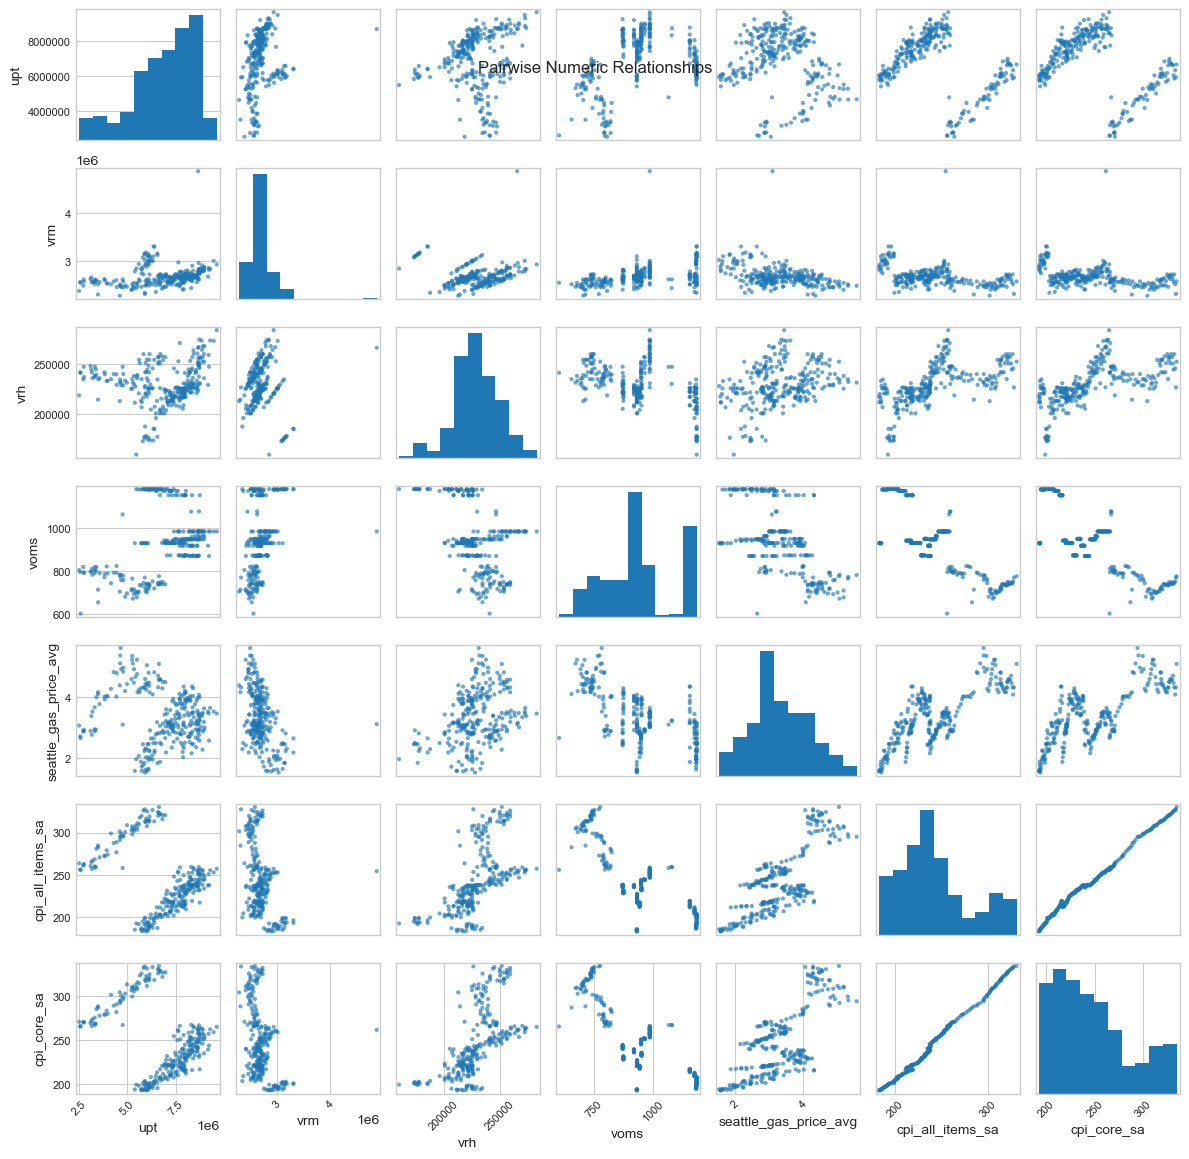

In [32]:
pairplot_cols = [c for c in ["upt", "vrm", "vrh", "voms", "seattle_gas_price_avg", "cpi_all_items_sa", "cpi_core_sa"] if c in df.columns]

if len(pairplot_cols) >= 2:
    axes = scatter_matrix(
        df[pairplot_cols].dropna(),
        figsize=(12, 12),
        diagonal="hist",
        alpha=0.65,
        grid=True,
    )
    for ax in axes.ravel():
        ax.tick_params(axis="x", labelrotation=45)
    plt.suptitle("Pairwise Numeric Relationships", y=0.92)
    plt.tight_layout()


## Initial Notes


In [33]:
notes = []

if "upt" in df.columns:
    upt_min_date = df.loc[df["upt"].idxmin(), "date"] if df["upt"].notna().any() else None
    upt_max_date = df.loc[df["upt"].idxmax(), "date"] if df["upt"].notna().any() else None
    notes.append({"check": "UPT range", "result": f"min at {upt_min_date.date()}, max at {upt_max_date.date()}"})

for group_name, cols in source_groups.items():
    present = [c for c in cols if c in df.columns]
    if present:
        first_complete = df.loc[df[present].notna().all(axis=1), "date"].min()
        notes.append({"check": f"{group_name} first complete month", "result": first_complete.date() if pd.notna(first_complete) else "none"})

pd.DataFrame(notes)


,check,result
0,UPT range,"min at 2021-02-01, max at 2019-10-01"
1,transit first complete month,2002-01-01
2,gas first complete month,2003-05-01
3,inflation first complete month,2002-01-01


## Next EDA Ideas

- Add YoY percent-change views for raw source columns, while keeping them labeled as EDA-only derived views.
- Compare pre-COVID, disruption, and recovery windows without adding model-facing regime flags yet.
- Add source-specific checks for whether availability dates match the as-of-date assumptions used later in feature engineering.
